# interpolation functions

In [1]:
import torchtt as tntt
import torch as tn
from utils import *

def d_coeff_mat(M, order=0):
    if order == 0:
        return M
    elif order == 1:
        return M[:, 1:] * tn.tensor([1, 2, 3], dtype=M.dtype)
    elif order == 2:
        return M[:, 2:] * tn.tensor([2, 6], dtype=M.dtype)
    else:
        raise ValueError("Only derivative orders 0, 1, and 2 are supported.")
    

def qtt_skcubic3d_p(mps, fscale, eps = 1e-15, order = 1, p_derivative = [0,0,0]):


    ni = len(mps.N)//3
    nc = fscale - ni 

    id0 = I_qtt(ni)
    ones = tntt.ones([2]*ni)
    onesf = tntt.ones([2]*nc)

    if order == 1:
        # Build Kernel interpolant
        Mkc = tn.tensor([
            [0, 2, 0, 0],
            [-1, 0, 1, 0],
            [2, -5, 4, -1],
            [-1, 3, -3, 1]
        ], dtype=tn.float64) /2
        Mkct = Mkc.t()

    elif order == 2:
        Mkct = tn.tensor([
            [1, -3, 3, -1],
            [4, 0, -6, 3],
            [1, 3, 3, -3],
            [0,0, 0, 1]
        ], dtype=tn.float64) /6

    sm10 = P_qtt( 2**ni -1, ni)
    O20 = P_qtt( 2**ni -2, ni)
    Om10 = P_qtt( 1, ni)

    epsp = 1e-10
    Mx = d_coeff_mat(Mkct, p_derivative[0]) 
    My = d_coeff_mat(Mkct, p_derivative[1])
    Mz = d_coeff_mat(Mkct, p_derivative[2])
    polsx = [tntt.kron( ones, zukron3(tntt.TT(qtt_polynomial_cores(Mx[i], nc)) , onesf,onesf) ).round(epsp) for i in range(4)]
    polsy = [tntt.kron( ones, zukron3( onesf , tntt.TT( qtt_polynomial_cores(My[i], nc)), onesf )).round(epsp) for i in range(4)]
    polsz = [tntt.kron( ones, zukron3( onesf , onesf , tntt.TT( qtt_polynomial_cores(Mz[i], nc)) )).round(epsp) for i in range(4)]
    
    zones3 = zukron3(onesf, onesf, onesf)

    oneso = tntt.eye([2]*nc)
    id = tntt.kron(id0,oneso)
    sm1 = tntt.kron(sm10,oneso)
    Om1 = tntt.kron(Om10,oneso)
    O2 = tntt.kron(O20,oneso)

    mps = tntt.kron(mps, zones3 )
    #interpolate y,
    f_ky = (zukron3(id,Om1,id) @ mps) * ( polsy[0] ) + ( mps * polsy[1] ) + ( zukron3(id,sm1,id) @ mps ) * (polsy[2]) + ( zukron3(id,O2,id) @ mps ) * (polsy[3]) 
    f_ky = f_ky.round(eps)

    #interpolate x
    f_kxy =  (zukron3(Om1,id,id) @ f_ky) *( polsx[0] ) + ( f_ky *  polsx[1] ) + ( zukron3(sm1,id,id) @ f_ky ) * (polsx[2]) +  ( zukron3(O2,id,id) @ f_ky ) * ( polsx[3])
    f_kxy = f_kxy.round(eps)

    #interpolate z
    f_kcs = (zukron3(id,id,Om1) @ f_kxy) * ( polsz[0] ) + ( f_kxy * polsz[1] ) + ( zukron3(id,id,sm1) @ f_kxy ) * (polsz[2]) + ( zukron3(id,id,O2) @ f_kxy ) * (polsz[3]) 
    f_kcs = f_kcs.round(eps)

    return f_kcs

c:\Users\siddhartha.morales\OneDrive - Technology Innovation Institute\Documents\GitHub\QTT-polynomial-interpolation\ttinter\Lib\site-packages\torchtt\_dmrg.py:19: UserWarning: 
C++ implementation not available. Using pure Python.

  warnings.warn("\x1B\nC++ implementation not available. Using pure Python.\n\033")
c:\Users\siddhartha.morales\OneDrive - Technology Innovation Institute\Documents\GitHub\QTT-polynomial-interpolation\ttinter\Lib\site-packages\torchtt\_amen.py:21: UserWarning: 
C++ implementation not available. Using pure Python.

  warnings.warn(
c:\Users\siddhartha.morales\OneDrive - Technology Innovation Institute\Documents\GitHub\QTT-polynomial-interpolation\ttinter\Lib\site-packages\torchtt\solvers.py:21: UserWarning: 
C++ implementation not available. Using pure Python.

  warnings.warn(
c:\Users\siddhartha.morales\OneDrive - Technology Innovation Institute\Documents\GitHub\QTT-polynomial-interpolation\ttinter\Lib\site-packages\torchtt\cpp.py:12: UserWarning: 
C++ impl

ModuleNotFoundError: No module named 'utils'

# Try car

In [ ]:
import os
import numpy as np
import trimesh

# Path to your OBJ file
filepath = "./objects/Ford_Edge_2008/26993_Ford_Edge_2008.obj"
assert os.path.isfile(filepath), f"File not found: {filepath}"

# Load mesh (handles Scene or Mesh)
scene = trimesh.load(filepath, process=False)
mesh = scene.dump(concatenate=True) if isinstance(scene, trimesh.Scene) else scene
print(mesh)
print('loaded')
# Compute bounds and extents
bounds = mesh.bounds  # [[minX,minY,minZ], [maxX,maxY,maxZ]]
extents = bounds[1] - bounds[0]

# QUICK & EASY: Voxelization with approximate control over voxel count
desired_N = 5  # approx. number of voxels along the longest axis
pitch = extents.max() / desired_N
vg = mesh.voxelized(pitch=pitch)
mask = vg.matrix.astype(np.uint8)
print("Approximate voxel grid shape:", mask.shape)
print('voxelizing')
# PRECISE CONTROL: Exact grid dimensions using mesh.contains
nx, ny, nz = 80, 60, 40  # desired dimensions
mn, mx = bounds
dx = (mx[0] - mn[0]) / nx
dy = (mx[1] - mn[1]) / ny
dz = (mx[2] - mn[2]) / nz

# Create grid of voxel centers
x = np.linspace(mn[0] + dx/2, mx[0] - dx/2, nx)
y = np.linspace(mn[1] + dy/2, mx[1] - dy/2, ny)
z = np.linspace(mn[2] + dz/2, mx[2] - dz/2, nz)
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')
pts = np.vstack((X.ravel(), Y.ravel(), Z.ravel())).T

# Test inside/outside
inside = mesh.contains(pts)
mask_precise = inside.reshape(nx, ny, nz).astype(np.uint8)
print("Precise mask shape:", mask_precise.shape)


C:\Users\siddhartha.morales\AppData\Local\Temp\ipykernel_49664\677873128.py:11: DeprecationWarning: `Scene.dump(concatenate=True)` DEPRECATED FOR REMOVAL APRIL 2025: replace with `Scene.to_geometry()`
  mesh = scene.dump(concatenate=True) if isinstance(scene, trimesh.Scene) else scene


<trimesh.Trimesh(vertices.shape=(23503, 3), faces.shape=(21777, 3))>
loaded
Approximate voxel grid shape: (3, 3, 6)
voxelizing


In [ ]:
import open3d as o3d
import numpy as np
filepath = "./objects/Ford_Edge_2008/26993_Ford_Edge_2008.obj"
# 1) Load your OBJ mesh
mesh = o3d.io.read_triangle_mesh(filepath)
if not mesh.has_vertex_normals():
    mesh.compute_vertex_normals()

# 2) Voxelize at a given resolution, e.g. 1 cm voxels
voxel_size = 0.01  # in same units as your OBJ
voxel_grid = o3d.geometry.VoxelGrid.create_from_triangle_mesh(mesh, voxel_size)

# 3) Inspect & extract occupancy
voxels = voxel_grid.get_voxels()       # list of occupied voxel coordinates
print(f"Occupied voxels: {len(voxels)}")

In [2]:
import numpy as np, trimesh
filepath = "./objects/Ford_Edge_2008/26993_Ford_Edge_2008.obj"
mesh = trimesh.load(filepath, process=False)
mn, mx = mesh.bounds
nx, ny, nz = 100, 100, 100
grid = np.stack(np.meshgrid(
    np.linspace(mn[0], mx[0], nx),
    np.linspace(mn[1], mx[1], ny),
    np.linspace(mn[2], mx[2], nz),
    indexing='ij'
), -1).reshape(-1,3)
inside = mesh.contains(grid)
mask = inside.reshape(nx, ny, nz).astype(np.uint8)


AttributeError: 'Scene' object has no attribute 'contains'

# Try Wing

In [25]:
%matplotlib ipympl

In [14]:
from utils import *

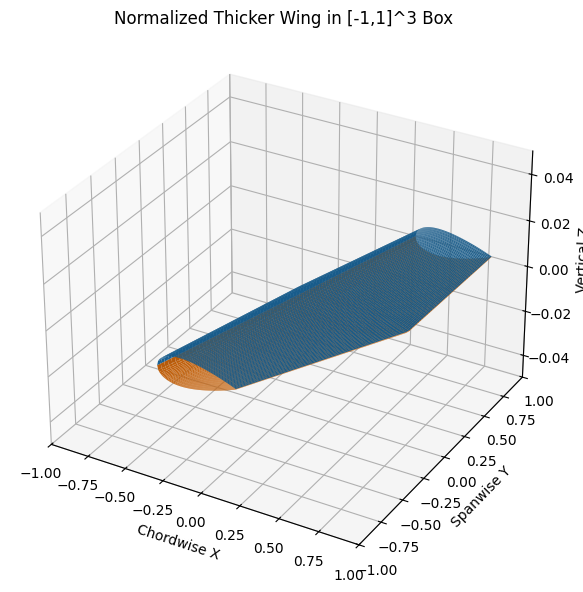

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Wing parameters
b = 2.0
c_r = 1.0
c_t = 0.5
Lambda_LE = np.deg2rad(15)
phi = 0*np.deg2rad(3)
t = 0.12

def chord(eta): return c_r*(1 - np.abs(eta))/2 + c_t*(1 + np.abs(eta))/2
def x_le(eta): return 0.5 * b * eta * np.tan(Lambda_LE)
def z_planform(eta): return 0.5 * b * eta * np.tan(phi)
def y_t(xi):
    return t * (0.2969 * np.sqrt(xi) - 0.1260 * xi - 0.3516 * xi**2 + 0.2843 * xi**3 - 0.1015 * xi**4)

eta_vals = np.linspace(-1, 1, 80)
xi_vals = np.linspace(0, 1, 80)
XI, ETA = np.meshgrid(xi_vals, eta_vals)

C = chord(ETA)
X_sec = XI * C
Z_thick = C * y_t(XI)

X = x_le(ETA) + X_sec
Y = 0.5 * b * ETA
Z_upper = z_planform(ETA) + Z_thick
Z_lower = z_planform(ETA) - Z_thick

max_val = max(np.abs(X).max(), np.abs(Y).max(), np.abs(Z_upper).max(), np.abs(Z_lower).max())
X /= max_val
Y /= max_val
Z_upper /= max_val
Z_lower /= max_val

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z_upper, rstride=1, cstride=1, shade=True)
ax.plot_surface(X, Y, Z_lower, rstride=1, cstride=1, shade=True)

ax.set_xlim([-1, 1])
ax.set_ylim([-1, 1])
ax.set_zlim([-.05, .05])

ax.set_xlabel('Chordwise X')
ax.set_ylabel('Spanwise Y')
ax.set_zlabel('Vertical Z')
ax.set_title('Normalized Thicker Wing in [-1,1]^3 Box')
plt.tight_layout()
plt.show()


Approximate max thickness at root chord: 0.01800516680438415


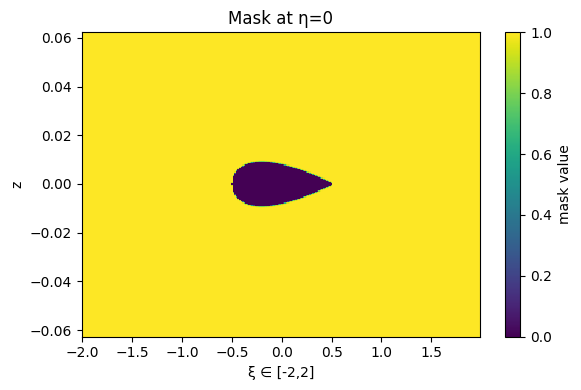

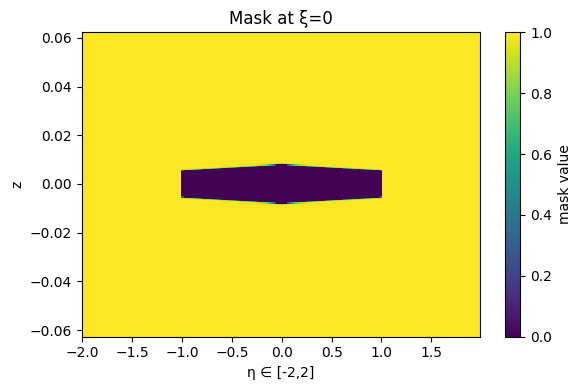

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Wing parameterization ---
b, c_r, c_t = 2.0, 1.0, 0.5
Lambda_LE = np.deg2rad(15)
phi       = 0.0
t         = 0.12

def chord(eta):
    return c_r*(1 - np.abs(eta))/2 + c_t*(1 + np.abs(eta))/2

def z_planform(eta):
    return 0.5 * b * eta * np.tan(phi)

def y_t(xi):
    return t*(0.2969 * np.sqrt(xi)
             - 0.1260 * xi
             - 0.3516 * xi**2
             + 0.2843 * xi**3
             - 0.1015 * xi**4)

# --- Create 3D grid over eta, xi, z  ---
p        = 8
zlim     = 1/16
eta_vals = np.linspace(-2,  2, 2**p, endpoint=False)  # ← extended from [-1,1]
xi_ext   = np.linspace(-2,  2, 2**p, endpoint=False)
z_vals   = np.linspace(-zlim, zlim, 2**p, endpoint=False)
ETA, XI, ZG = np.meshgrid(eta_vals, xi_ext, z_vals, indexing='ij')

# --- Valid chordwise band for surface definition (xi in [-0.5,0.5]) ---
mask_band = (XI[:,:,0] >= -0.5) & (XI[:,:,0] <= 0.5)

# Compute 2D upper/lower z in that band
Zup2d  = np.zeros_like(ETA[:,:,0])
Zlow2d = np.zeros_like(ETA[:,:,0])

xi_param = XI[:,:,0][mask_band] + 0.5
eta_m    = ETA[:,:,0][mask_band]
C_m      = chord(eta_m)
Zt       = C_m * y_t(xi_param)

Zup2d[mask_band]  = z_planform(eta_m) + Zt
Zlow2d[mask_band] = z_planform(eta_m) - Zt

# Broadcast to 3D
Zup3d  = Zup2d[:,:,None] * np.ones_like(ZG)
Zlow3d = Zlow2d[:,:,None] * np.ones_like(ZG)

# Precompute thickness scale
xi_test      = np.linspace(0,1,1000)
max_y_t      = np.max(y_t(xi_test))
c_root       = chord(0.0)
real_thick   = 2 * c_root * max_y_t
print("Approximate max thickness at root chord:", real_thick)

# --- Build mask, default = 1 everywhere ---
mask = np.ones_like(ZG)

# Define the “core” region in eta and xi:
mask_eta = (ETA[:,:,0] >= -1.0) & (ETA[:,:,0] <= 1.0)
mask_xi  = (XI[:,:,0]  >= -1.0) & (XI[:,:,0]  <= 1.0)
mask_core = mask_eta & mask_xi

# 1) Inside wing (flat) → mask = 0
inside = mask_core[:,:,None] & mask_band[:,:,None] & (ZG >= Zlow3d) & (ZG <= Zup3d)
mask[inside] = 0.0

# 2) Above upper surface → exponential falloff
above = mask_core[:,:,None] & mask_band[:,:,None] & (ZG > Zup3d)
zd_above = ZG - Zup3d
mask[above] = 1 - np.exp(-(1000/real_thick) * zd_above[above])

# 3) Below lower surface → exponential falloff
below = mask_core[:,:,None] & mask_band[:,:,None] & (ZG < Zlow3d)
zd_below = Zlow3d - ZG
mask[below] = 1 - np.exp(-(1000/real_thick) * zd_below[below])

# --- Optional: visualize central slices ---
# η = 0 slice
i0 = np.argmin(np.abs(eta_vals - 0.0))
plt.figure(figsize=(6,4))
plt.pcolormesh(xi_ext, z_vals, mask[i0,:,:].T, shading='auto', cmap='viridis')
plt.xlabel('ξ ∈ [-2,2]')
plt.ylabel('z')
plt.title('Mask at η=0')
plt.colorbar(label='mask value')
plt.tight_layout()
plt.show()

# ξ = 0 slice
j0 = np.argmin(np.abs(xi_ext - 0.0))
plt.figure(figsize=(6,4))
plt.pcolormesh(eta_vals, z_vals, mask[:,j0,:].T, shading='auto', cmap='viridis')
plt.xlabel('η ∈ [-2,2]')
plt.ylabel('z')
plt.title('Mask at ξ=0')
plt.colorbar(label='mask value')
plt.tight_layout()
plt.show()


In [ ]:
rgba = np.zeros((mask.size, 4))
rgba[:, 3] = (1 - mask).ravel()  # now inside (mask=0) → alpha=1, outside (mask→1) → alpha→0

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(
    ETA.ravel(), XI.ravel(), ZG.ravel(), c=rgba,marker='o', s=10
)
ax.set_xlabel('x (normalized)')
ax.set_ylabel('y (normalized)')
ax.set_zlabel('z (physical)')
ax.set_title('3D Mask: Outside Black → Inside Transparent')
ax.set_zlim(-zlim, zlim)
plt.tight_layout()
plt.show()

In [7]:
def compute_morton3_indices(n: int) -> tn.Tensor:
    """
    Build a (2**n,2**n,2**n) tensor of 3D Morton codes by bit‑interleaving.
    morton[i,j,k] = interleave_bits(i,j,k).
    """
    N = 2**n
    idx = tn.arange(N, dtype=tn.long)
    i, j, k = tn.meshgrid(idx, idx, idx, indexing='ij')    # each is shape (N,N,N)
    morton = tn.zeros_like(i)

    for bit in range(n):
        morton |= ((i >> bit) & 1) << (3*bit)
        morton |= ((j >> bit) & 1) << (3*bit + 1)
        morton |= ((k >> bit) & 1) << (3*bit + 2)

    return morton


def zM3(M: tn.Tensor, n: int) -> tn.Tensor:
    """
    Rearrange a (2**n,2**n,2**n) tensor M into Z‑order (Morton) curve.
    
    After this, flattening M_z in row‑major (i.e. M_z.view(-1)) will
    traverse M in 3D Morton order.
    """
    N = 2**n
    # 1) compute 3D Morton codes for each (i,j,k)
    morton = compute_morton3_indices(n)    # shape (N,N,N), values in [0, N^3-1]

    # 2) invert row-major flatten:
    #    flat_idx = new_i*N*N + new_j*N + new_k  =>  morton
    new_i = morton // (N*N)
    rem   = morton %  (N*N)
    new_j = rem   // N
    new_k = rem   %  N

    # 3) scatter
    M_z = tn.empty_like(M)
    idx = tn.arange(N, dtype=tn.long)
    old_i, old_j, old_k = tn.meshgrid(idx, idx, idx, indexing='ij')

    M_z[new_i, new_j, new_k] = M[old_i, old_j, old_k]
    return M_z


def z_order_to_normal_nopara(z_order, normal, dim0, dim1, dim2):
    n = z_order.size
    for i in range(n):
        code = i
        x = y = z = bit = 0
        while code:
            z |= (code & 1) << bit;  code >>= 1
            y |= (code & 1) << bit;  code >>= 1
            x |= (code & 1) << bit;  code >>= 1
            bit += 1

        if x < dim0 and y < dim1 and z < dim2:
            normal[x, y, z] = z_order[i]
    return normal

In [5]:
tnmask = tn.tensor(mask,dtype=tn.float64)
tz = tn.zeros_like(tnmask)
x_order = bit_reverse_indices(p)
for i in range(2**p):
    tz[i,:,:] = zM(tnmask[i,:,:],p)
tz = tz[x_order,:,:]
ttmask = tntt.TT(tz,[2]*p+[2,2]*p,eps=1e-3)
print(np.max(ttmask.R))


129


In [6]:
qttmask = tntt.TT(zM3(tnmask,p),[2,2,2]*p,eps=1e-3)
#tmf = z_order_to_normal_nopara(qttmask.full().cpu().numpy().ravel(), np.zeros((2**p, 2**p, 2**p)), 2**p, 2**p, 2**p).T
np.max(qttmask.R)

np.int64(221)

In [52]:
N = 2**p
tmfull = ttmask.full().reshape(N,N,N)
print(tmfull.shape)
tmf = tn.zeros(N,N,N)
for i in range(2**p):
    tmf[i,:,:] = z_order_to_normal_torch(tmfull[i,:,:].flatten(),N,N).T
tmf = tmf[x_order,:,:]
tmf = tmf.cpu().numpy()


torch.Size([128, 128, 128])


In [53]:
np.linalg.norm(tmf - mask)/np.linalg.norm(mask)

np.float64(0.0006969791781511382)

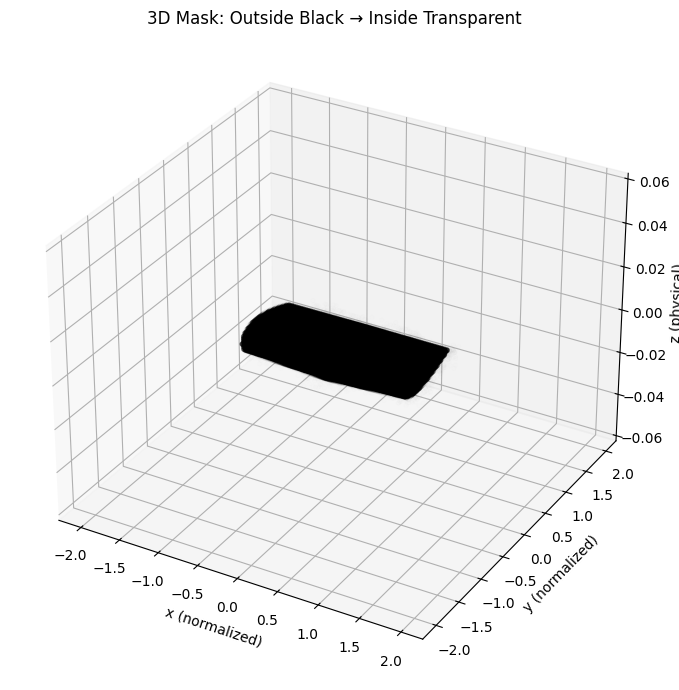

In [72]:


# --- Invert alpha: alpha = 1 - mask ---
rgba = np.zeros((tmf.size, 4))
rgba[:, 3] = (1 - tmf).ravel()  # now inside (mask=0) → alpha=1, outside (mask→1) → alpha→0
# Min-max normalization of alpha channel (rgba[:, 3]) to [0, 1]
rgba = np.clip(rgba, 0, 1)

# Plot 3D scatter with transparency
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(
    ETA.ravel(), XI.ravel(), ZG.ravel(), c=rgba,marker='o', s=10
)
ax.set_xlabel('x (normalized)')
ax.set_ylabel('y (normalized)')
ax.set_zlabel('z (physical)')
ax.set_title('3D Mask: Outside Black → Inside Transparent')
ax.set_zlim(-zlim, zlim)
plt.tight_layout()
plt.show()

In [ ]:
qtt_int = qtt_skcubic3d_p(qttmask, 9, eps = 1e-3)
qtt_int

TT with sizes and ranks:
N = [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
R = [1, 2, 4, 8, 9, 9, 17, 17, 22, 31, 41, 70, 106, 123, 121, 91, 59, 40, 29, 21, 15, 12, 9, 8, 5, 3, 2, 1]

Device: cpu, dtype: torch.float64
#entries 124844 compression 0.0009301602840423584

In [124]:
pp=9
N = 2**pp
mask_int = z_order_to_normal_nopara(qtt_int.full().cpu().numpy().ravel(),np.zeros((N,N,N)),N,N,N).T

In [125]:
eta_vals = np.linspace(-2,  2, 2**pp, endpoint=False)  # ← extended from [-1,1]
xi_ext   = np.linspace(-2,  2, 2**pp, endpoint=False)
z_vals   = np.linspace(-zlim, zlim, 2**pp, endpoint=False)

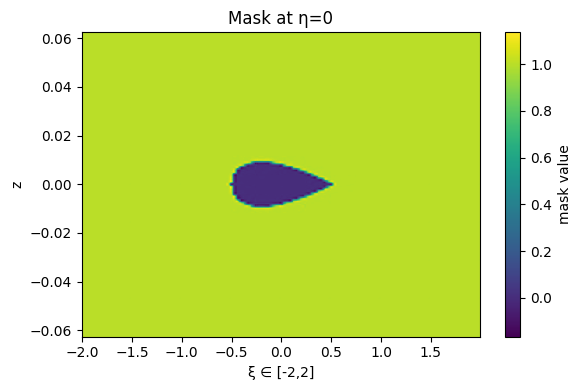

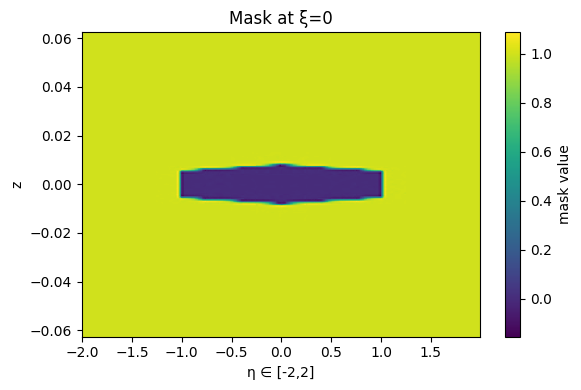

In [126]:
# η = 0 slice
i0 = np.argmin(np.abs(eta_vals - 0.0))
plt.figure(figsize=(6,4))
plt.pcolormesh(xi_ext, z_vals, mask_int[i0,:,:].T, shading='auto', cmap='viridis')
plt.xlabel('ξ ∈ [-2,2]')
plt.ylabel('z')
plt.title('Mask at η=0')
plt.colorbar(label='mask value')
plt.tight_layout()
plt.show()

# ξ = 0 slice
j0 = np.argmin(np.abs(xi_ext - 0.0))
plt.figure(figsize=(6,4))
plt.pcolormesh(eta_vals, z_vals, mask_int[:,j0,:].T, shading='auto', cmap='viridis')
plt.xlabel('η ∈ [-2,2]')
plt.ylabel('z')
plt.title('Mask at ξ=0')
plt.colorbar(label='mask value')
plt.tight_layout()
plt.show()

In [ ]:
tensor = mask.astype(float)
tensor = np.transpose(tensor,axes=[0,1,2])

# --- 2) HOSVD / Tucker decomposition ---
def unfold(X, mode):
    return np.moveaxis(X, mode, 0).reshape(X.shape[mode], -1)

def fold(mat, mode, shape):
    full = [shape[mode]] + [s for i, s in enumerate(shape) if i != mode]
    return np.moveaxis(mat.reshape(full), 0, mode)

# Define mode-n product
def mode_n_prod(X, M, mode):
    shape = X.shape
    unfolded = np.moveaxis(X, mode, 0).reshape(shape[mode], -1)
    prod = M @ unfolded
    new_shape = list(shape)
    new_shape[mode] = M.shape[0]
    folded = prod.reshape([M.shape[0]] + [shape[i] for i in range(len(shape)) if i != mode])
    return np.moveaxis(folded, 0, mode)

# Assuming U list from truncated SVD as U[0]=U1_r, U[1]=U2_r, U[2]=U3_r
# Re-compute U here for self-containment:
rt = 60
ranks = (rt, rt, rt)
U = []

for mode, r in enumerate(ranks):
    mat = np.moveaxis(tensor, mode, 0).reshape(tensor.shape[mode], -1)
    u, s, vh = np.linalg.svd(mat, full_matrices=False)
    U.append(u[:, :r])

# 1) Compute core via successive mode-n products with U^T
core = tensor.copy()
for mode in range(3):
    core = mode_n_prod(core, U[mode].T, mode)

# 2) Reconstruct from core and U
recon = core.copy()
for mode in range(3):
    recon = mode_n_prod(recon, U[mode], mode)

# 3) Compute L2 error
err_abs = np.linalg.norm(tensor - recon)
err_rel = err_abs / np.linalg.norm(tensor)

print(f"Absolute L2 error: {err_abs:.6e}")
print(f"Relative   error: {err_rel:.6e}")


Absolute L2 error: 6.103624e+00
Relative   error: 5.297265e-04


In [144]:
tntt.TT(core,[rt]*3).round(1e-6)

TT with sizes and ranks:
N = [60, 60, 60]
R = [1, 60, 39, 1]

Device: cpu, dtype: torch.float64
#entries 146340 compression 0.6775

In [149]:
tntt.TT( U[1].reshape(rt,2**p), [rt]+[2]*p,eps=1e-3)

TT with sizes and ranks:
N = [60, 2, 2, 2, 2, 2, 2, 2, 2, 2]
R = [1, np.int64(46), np.int64(76), 128, 64, 32, 16, 8, 4, 2, 1]

Device: cpu, dtype: torch.float64
#entries 51052 compression 1.6618489583333333

In [8]:
%matplotlib ipympl

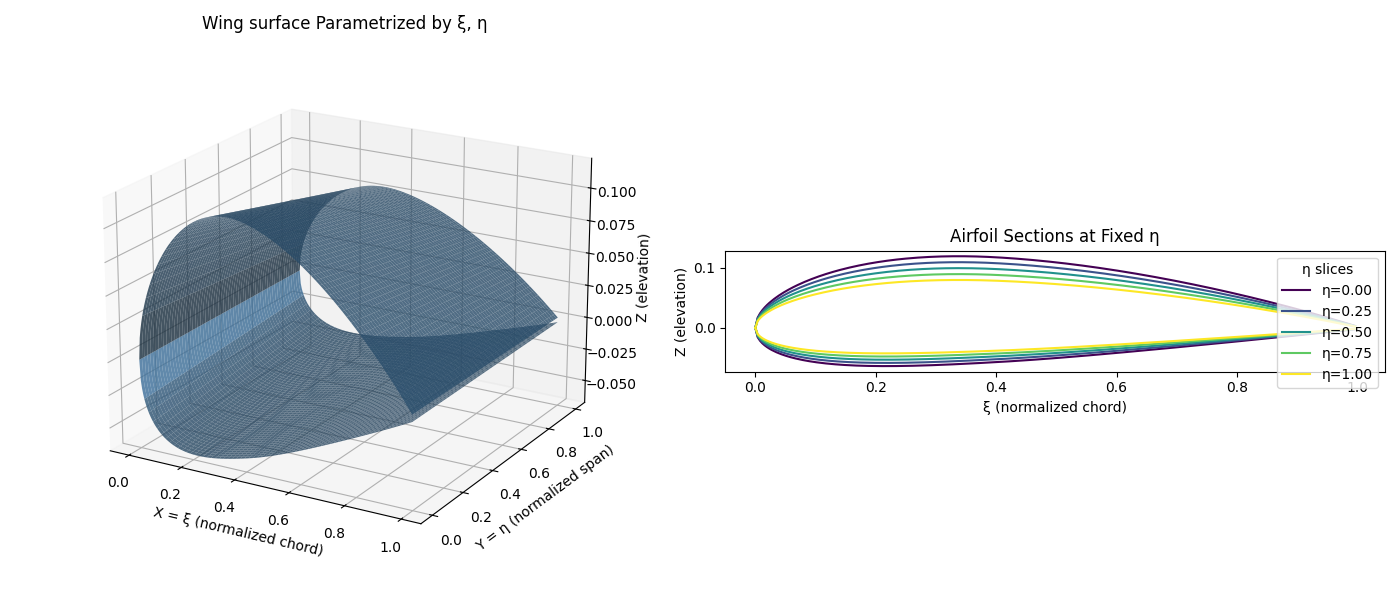

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ─── Wing parameters ───────────────────────────────────────────────────────────
b, c_r, c_t    = 10.0, 2.0, 1.0      # span, root & tip chord (unused in X,Y here)
Lambda_LE      = np.deg2rad(25)      # sweep (unused in X,Y here)
m, p_cam, t    = 0.02, 0.4, 0.12     # camber & thickness parameters

def chord(eta):
    return c_r * (1 - eta)/2 + c_t * (1 + eta)/2

def thickness_dist(xi):
    return 5*t * (
        0.2969*np.sqrt(xi)
        -0.1260*xi
        -0.3516*xi**2
        +0.2843*xi**3
        -0.1015*xi**4
    )

def camber_line(xi):
    yc = np.where(
        xi < p_cam,
        m/(p_cam**2)*(2*p_cam*xi - xi**2),
        m/((1-p_cam)**2)*((1-2*p_cam) + 2*p_cam*xi - xi**2)
    )
    dyc = np.where(
        xi < p_cam,
        2*m/(p_cam**2)*(p_cam - xi),
        2*m/((1-p_cam)**2)*(p_cam - xi)
    )
    return yc, dyc

# ─── Grid definition ──────────────────────────────────────────────────────────
p = 8
N = 2**p

# ξ, η ∈ [0,1), endpoint=False
xi_vals  = np.linspace(0.0, 1.0, N, endpoint=False)
eta_vals = np.linspace(0.0, 1.0, N, endpoint=False)

# 2D parametric grid: XI along X, ETA along Y
XI, ETA = np.meshgrid(xi_vals, eta_vals, indexing='ij')

# ─── Compute camber & thickness in 2D ────────────────────────────────────────
C      = chord(ETA)               # chord length (for scaling Z)
yc, _  = camber_line(XI)          # camber fraction
yt     = thickness_dist(XI)       # half-thickness fraction

# ─── Embed in 3D: X=ξ, Y=η, Z=surface elevation ─────────────────────────────
X       = XI
Y       = ETA

Z_upper = yc*C + yt*C
Z_lower = yc*C - yt*C

# ─── Plot the 3D wing surface ───────────────────────────────────────────────
fig = plt.figure(figsize=(14,6))
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X, Y, Z_upper, rstride=4, cstride=4, color='steelblue', alpha=0.8)
ax1.plot_surface(X, Y, Z_lower, rstride=4, cstride=4, color='steelblue', alpha=0.8)
ax1.set_xlabel('X = ξ (normalized chord)'); ax1.set_ylabel('Y = η (normalized span)')
ax1.set_zlabel('Z (elevation)')
ax1.set_title('Wing surface Parametrized by ξ, η')
ax1.view_init(elev=20, azim=-60)

# ─── Plot airfoil sections at constant η slices ──────────────────────────────
ax2 = fig.add_subplot(122)
eta_slices = [0.0, 0.25, 0.5, 0.75, 1.0]
colors     = plt.cm.viridis(np.linspace(0,1,len(eta_slices)))
for η, col in zip(eta_slices, colors):
    j = np.argmin(np.abs(eta_vals - η))
    ax2.plot(xi_vals, Z_upper[:, j], color=col)
    ax2.plot(xi_vals, Z_lower[:, j], color=col, label=f'η={η:.2f}')

ax2.set_aspect('equal')
ax2.set_xlabel('ξ (normalized chord)')
ax2.set_ylabel('Z (elevation)')
ax2.set_title('Airfoil Sections at Fixed η')
ax2.legend(title='η slices', loc='upper right')

plt.tight_layout()
plt.show()


C:\Users\siddhartha.morales\AppData\Local\Temp\ipykernel_32760\1677919756.py:13: RuntimeWarning: invalid value encountered in sqrt
  return 5*t*(0.2969*np.sqrt(xi)


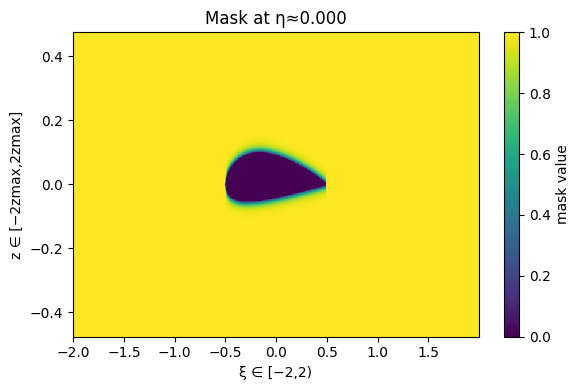

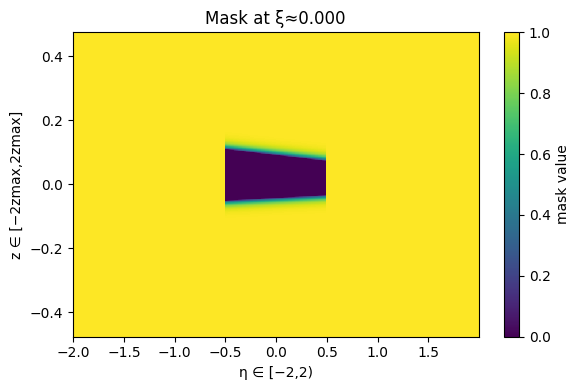

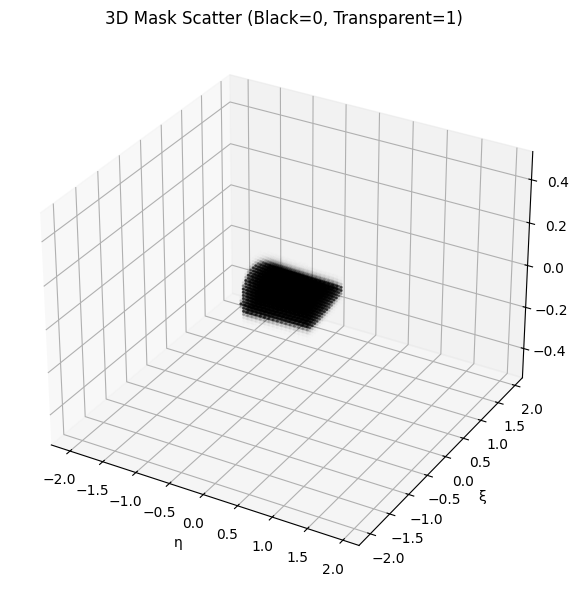

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ─── Wing parameters ─────────────────────────────────────────────────────────
b, c_r, c_t = 10.0, 2.0, 1.0
Lambda_LE   = np.deg2rad(25)
m, p_cam, t = 0.02, 0.4, 0.12

def chord(eta):
    return c_r*(1 - eta)/2 + c_t*(1 + eta)/2

def thickness_dist(xi):
    return 5*t*(0.2969*np.sqrt(xi)
                -0.1260*xi
                -0.3516*xi**2
                +0.2843*xi**3
                -0.1015*xi**4)

def camber_line(xi):
    yc = np.where(xi < p_cam,
                  m/(p_cam**2)*(2*p_cam*xi - xi**2),
                  m/((1-p_cam)**2)*((1-2*p_cam) + 2*p_cam*xi - xi**2))
    return yc, None

# ─── 1) Compute z_max on the original [0,1)×[0,1) grid ─────────────────────
p = 9
N = 2**p

eta_core = np.linspace(0.0, 1.0, N, endpoint=False)
xi_core  = np.linspace(0.0, 1.0, N, endpoint=False)
ETA2, XI2 = np.meshgrid(eta_core, xi_core, indexing='ij')

C2     = chord(ETA2)
yc2, _ = camber_line(XI2)
yt2    = thickness_dist(XI2)

Zup2   = yc2*C2 + yt2*C2
Zlow2  = yc2*C2 - yt2*C2

zmax = np.max(np.abs([Zup2, Zlow2]))

# ─── 2) Build the extended grid η,ξ ∈ [−2,2), z ∈ [−2zmax,2zmax) ─────────────
eta_vals = np.linspace(-2.0, 2.0, N, endpoint=False)
xi_vals  = np.linspace(-2.0, 2.0, N, endpoint=False)
z_vals   = np.linspace(-4*zmax, 4*zmax, N, endpoint=False)

ETA3, XI3, ZG = np.meshgrid(eta_vals, xi_vals, z_vals, indexing='ij')

# ─── 3) Map extended coords back to “core” params and gate core region ───────
eta_mapped = ETA3 + 0.5   # now [−2,2)→[−1.5,2.5); core is [0,1)
xi_mapped  = XI3  + 0.5   # same
core_mask  = (
    (eta_mapped >= 0) & (eta_mapped < 1) &
    (xi_mapped  >= 0) & (xi_mapped  < 1)
)

# ─── 4) Compute wing surfaces at those mapped params ─────────────────────────
C3      = chord(eta_mapped)
yc3, _  = camber_line(xi_mapped)
yt3     = thickness_dist(xi_mapped)

Zup3    = yc3*C3 + yt3*C3
Zlow3   = yc3*C3 - yt3*C3

# ─── 5) Build the embedded mask ──────────────────────────────────────────────
mask = np.ones_like(ZG)

# inside wing → 0
inside = core_mask & (ZG >= Zlow3) & (ZG <= Zup3)
mask[inside] = 0.0

# above wing → 1 − exp(−100·Δz)
above = core_mask & (ZG > Zup3)
mask[above] = 1.0 - np.exp(-100.0 * (ZG[above] - Zup3[above]))

# below wing → 1 − exp(−100·Δz)
below = core_mask & (ZG < Zlow3)
mask[below] = 1.0 - np.exp(-100.0 * (Zlow3[below] - ZG[below]))

# ─── 6) Visualize central η‐slice and central ξ‐slice ────────────────────────
i_eta0 = np.argmin(np.abs(eta_vals - 0.0))
plt.figure(figsize=(6,4))
plt.pcolormesh(xi_vals, z_vals, mask[i_eta0,:,:].T, shading='auto')
plt.xlabel('ξ ∈ [−2,2)')
plt.ylabel('z ∈ [−2zmax,2zmax]')
plt.title(f'Mask at η≈{eta_vals[i_eta0]:.3f}')
plt.colorbar(label='mask value')
plt.tight_layout()
plt.show()

j_xi0 = np.argmin(np.abs(xi_vals - 0.0))
plt.figure(figsize=(6,4))
plt.pcolormesh(eta_vals, z_vals, mask[:,j_xi0,:].T, shading='auto')
plt.xlabel('η ∈ [−2,2)')
plt.ylabel('z ∈ [−2zmax,2zmax]')
plt.title(f'Mask at ξ≈{xi_vals[j_xi0]:.3f}')
plt.colorbar(label='mask value')
plt.tight_layout()
plt.show()

# ─── 7) 3D scatter of mask values ────────────────────────────────────────────
# Downsample for performance
step = 8
X_s = ETA3[::step, ::step, ::step].flatten()
Y_s = XI3[::step, ::step, ::step].flatten()
Z_s = ZG[::step, ::step, ::step].flatten()
m_s = mask[::step, ::step, ::step].flatten()

# RGBA: black when mask=0, transparent when mask=1
colors = np.zeros((m_s.size, 4))
colors[:, 3] = 1.0 - m_s  # alpha channel

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_s, Y_s, Z_s, color=colors, s=2)
ax.set_xlabel('η')
ax.set_ylabel('ξ')
ax.set_zlabel('z')
ax.set_title('3D Mask Scatter (Black=0, Transparent=1)')
plt.tight_layout()
plt.show()


In [14]:


m = tn.tensor(mask, dtype=tn.float64)
#m = tn.permute(m, (0, 1, 2))  # ensure shape is (N, N, N)
twing = tntt.TT(zM3(m,p), [2,2,2]*p,eps=1e-3)

np.max(twing.R)

np.int64(101)

In [15]:
tnmask = tn.tensor(mask,dtype=tn.float64)
tz = tn.zeros_like(tnmask)
x_order = bit_reverse_indices(p)
for i in range(2**p):
    tz[i,:,:] = zM(tnmask[i,:,:],p)
tz = tz[x_order,:,:]
ttmask = tntt.TT(tz,[2]*p+[2,2]*p,eps=1e-3)
print(np.max(ttmask.R))


69


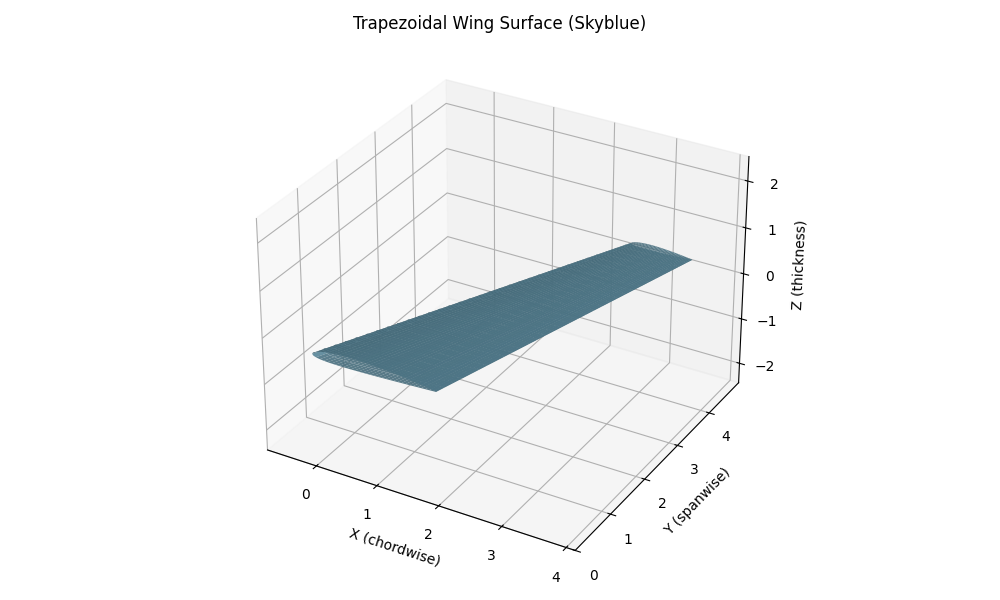

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def generate_trapezoidal_wing_surface(
    b=10.0, c_root=2.0, c_tip=1.0,
    sweep_LE=np.deg2rad(25),
    m=0.02, p_cam=0.4, t=0.12,
    N=128
):
    eta = np.linspace(0,1,N,endpoint=False)
    xi  = np.linspace(0,1,N,endpoint=False)
    XI, ETA = np.meshgrid(xi, eta, indexing='ij')

    # chord, camber, thickness
    C  = c_root*(1-ETA) + c_tip*ETA
    yc = np.where(
        XI<p_cam,
        m/(p_cam**2)*(2*p_cam*XI - XI**2),
        m/((1-p_cam)**2)*((1-2*p_cam)+2*p_cam*XI - XI**2)
    )
    yt = 5*t*(0.2969*np.sqrt(XI)
             -0.1260*XI
             -0.3516*XI**2
             +0.2843*XI**3
             -0.1015*XI**4)

    # coordinates
    x_le = 0.5 * b * ETA * np.tan(sweep_LE)
    X = x_le + XI*C
    Y = 0.5 * b * ETA
    Zup = (yc+yt)*C
    Zlo = (yc-yt)*C

    return X, Y, Zup, Zlo

# plot
X, Y, Zup, Zlo = generate_trapezoidal_wing_surface()
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Zup,  rstride=4, cstride=4, color='#87CEEB', edgecolor='none', alpha=0.9)
ax.plot_surface(X, Y, Zlo,  rstride=4, cstride=4, color='#87CEEB', edgecolor='none', alpha=0.9)

# equal aspect
max_range = np.array([X.max()-X.min(), Y.max()-Y.min(), Zup.max()-Zlo.min()]).max()/2
mid_x = (X.max()+X.min())/2
mid_y = (Y.max()+Y.min())/2
mid_z = (Zup.max()+Zlo.min())/2
ax.set_xlim(mid_x-max_range, mid_x+max_range)
ax.set_ylim(mid_y-max_range, mid_y+max_range)
ax.set_zlim(mid_z-max_range, mid_z+max_range)

ax.set_xlabel('X (chordwise)')
ax.set_ylabel('Y (spanwise)')
ax.set_zlabel('Z (thickness)')
ax.set_title('Trapezoidal Wing Surface (Skyblue)')
plt.tight_layout()
plt.show()


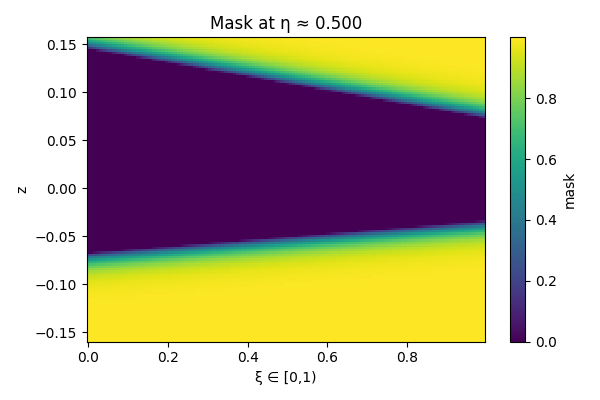

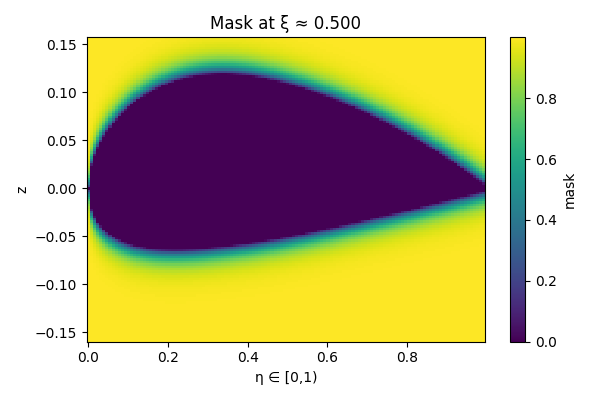

In [37]:
import numpy as np
import matplotlib.pyplot as plt

# ─── Wing surface function (from last version) ──────────────────────────────
def generate_trapezoidal_wing_surface(
    b=10.0, c_root=2.0, c_tip=1.0,
    sweep_LE=np.deg2rad(25),
    m=0.02, p_cam=0.4, t=0.12,
    N=128
):
    eta = np.linspace(0,1,N,endpoint=False)
    xi  = np.linspace(0,1,N,endpoint=False)
    XI, ETA = np.meshgrid(xi, eta, indexing='ij')

    # chord, camber, thickness
    C  = c_root*(1-ETA) + c_tip*ETA
    yc = np.where(
        XI < p_cam,
        m/(p_cam**2)*(2*p_cam*XI - XI**2),
        m/((1-p_cam)**2)*((1-2*p_cam)+2*p_cam*XI - XI**2)
    )
    yt = 5*t*(0.2969*np.sqrt(XI)
             -0.1260*XI
             -0.3516*XI**2
             +0.2843*XI**3
             -0.1015*XI**4)

    # coordinates with sweep
    x_le = 0.5 * b * ETA * np.tan(sweep_LE)
    X = x_le + XI*C
    Y = 0.5 * b * ETA
    Zup = (yc + yt)*C
    Zlo = (yc - yt)*C

    return eta, xi, X, Y, Zup, Zlo

# ─── 1) Generate wing surface ───────────────────────────────────────────────
eta, xi, Xw, Yw, Zup, Zlo = generate_trapezoidal_wing_surface()
N = Xw.shape[0]  # grid size

# ─── 2) Define z-grid based on wing thickness ───────────────────────────────
zlim = np.max(np.abs([Zup, Zlo]))
z_vals = np.linspace(-zlim, zlim, N, endpoint=False)

# ─── 3) Build 3D grid (η, ξ, z) ──────────────────────────────────────────────
ETA3, XI3, ZG = np.meshgrid(eta, xi, z_vals, indexing='ij')

# ─── 4) Broadcast wing surfaces to 3D ───────────────────────────────────────
Zup3d  = Zup[:, :, None]  # shape (N, N, 1)
Zlow3d = Zlo[:, :, None]

# ─── 5) Initialize mask = 1 everywhere ─────────────────────────────────────
mask = np.ones_like(ZG)

# 5a) Inside wing: z between lower and upper surfaces → mask = 0
inside = (ZG >= Zlow3d) & (ZG <= Zup3d)
mask[inside] = 0.0

# 5b) Above wing: mask = 1 - exp(-100 * (z - Zup))
zd_above = ZG - Zup3d
above = zd_above > 0
mask[above] = 1.0 - np.exp(-100.0 * zd_above[above])

# 5c) Below wing: mask = 1 - exp(-100 * (Zlow - z))
zd_below = Zlow3d - ZG
below = zd_below > 0
mask[below] = 1.0 - np.exp(-100.0 * zd_below[below])

# ─── 6) Visualize a central spanwise (η) slice ──────────────────────────────
i_mid = N//2
plt.figure(figsize=(6,4))
plt.pcolormesh(xi, z_vals, mask[i_mid,:,:].T, shading='auto', cmap='viridis')
plt.xlabel('ξ ∈ [0,1)')
plt.ylabel('z')
plt.title(f'Mask at η ≈ {eta[i_mid]:.3f}')
plt.colorbar(label='mask')
plt.tight_layout()
plt.show()

# ─── 7) Visualize a central chordwise (ξ) slice ─────────────────────────────
j_mid = N//2
plt.figure(figsize=(6,4))
plt.pcolormesh(eta, z_vals, mask[:,j_mid,:].T, shading='auto', cmap='viridis')
plt.xlabel('η ∈ [0,1)')
plt.ylabel('z')
plt.title(f'Mask at ξ ≈ {xi[j_mid]:.3f}')
plt.colorbar(label='mask')
plt.tight_layout()
plt.show()


C:\Users\siddhartha.morales\AppData\Local\Temp\ipykernel_32760\3135391486.py:70: RuntimeWarning: invalid value encountered in sqrt
  yt_g = 5*t*(0.2969*np.sqrt(xi_g)


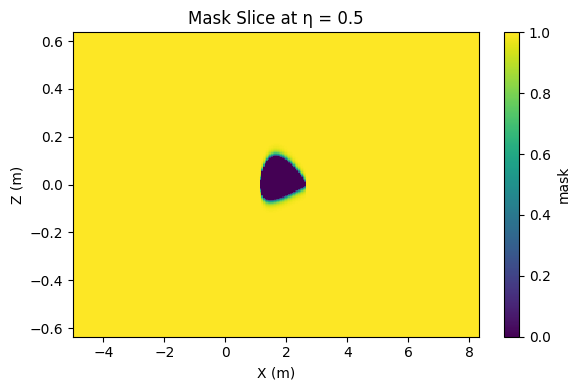

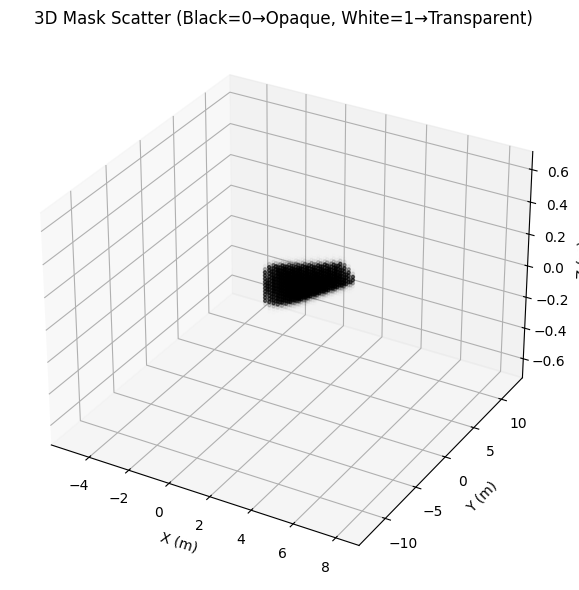

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ─── 1) Core wing surface function ───────────────────────────────────────────
def generate_trapezoidal_wing_surface(
    b=10.0, c_root=2.0, c_tip=1.0,
    sweep_LE=np.deg2rad(25),
    m=0.02, p_cam=0.4, t=0.12,
    N=128
):
    eta = np.linspace(0,1,N,endpoint=False)
    xi  = np.linspace(0,1,N,endpoint=False)
    XI, ETA = np.meshgrid(xi, eta, indexing='ij')

    C  = c_root*(1-ETA) + c_tip*ETA
    yc = np.where(XI<p_cam,
                  m/(p_cam**2)*(2*p_cam*XI - XI**2),
                  m/((1-p_cam)**2)*(1-2*p_cam + 2*p_cam*XI - XI**2))
    yt = 5*t*(0.2969*np.sqrt(XI)
             -0.1260*XI
             -0.3516*XI**2
             +0.2843*XI**3
             -0.1015*XI**4)

    x_le = 0.5 * b * ETA * np.tan(sweep_LE)
    Xw  = x_le + XI * C
    Yw  = 0.5 * b * ETA
    Zup = (yc + yt) * C
    Zlo = (yc - yt) * C

    return Xw, Yw, Zup, Zlo, b

# Generate wing surface
Xw, Yw, Zup, Zlo, b = generate_trapezoidal_wing_surface(N=128)

# ─── 2) Build mask in extended domain (2× larger) ───────────────────────────
# Wing bounding box
xmin, xmax = Xw.min(), Xw.max()
ymin, ymax = Yw.min(), Yw.max()
zlim = np.max(np.abs([Zup, Zlo]))

# Extended domain twice as large around center
mid_x = 0.5*(xmin + xmax)
mid_y = 0.5*(ymin + ymax)
half_dx = (xmax - xmin)
half_dy = (ymax - ymin)

N_dom = 2**8
X_vals = np.linspace(mid_x - 2*half_dx, mid_x + 2*half_dx, N_dom)
Y_vals = np.linspace(mid_y - 3*half_dy, mid_y + 2*half_dy, N_dom)
Z_vals = np.linspace(-4*zlim, 4*zlim, N_dom)

Xg, Yg, Zg = np.meshgrid(X_vals, Y_vals, Z_vals, indexing='ij')

# Map to (eta, xi)
eta_g = Yg / (0.5*b)
x_le_g = 0.5 * b * eta_g * np.tan(np.deg2rad(25))
C_g = (2.0*(1-eta_g) + 1.0*eta_g)  # chord
xi_g = (Xg - x_le_g) / C_g

# Core region
core = (eta_g>=0)&(eta_g<1)&(xi_g>=0)&(xi_g<1)

# Surfaces
m, p_cam, t = 0.02, 0.4, 0.12
yc_g = np.where(xi_g<p_cam,
                m/(p_cam**2)*(2*p_cam*xi_g - xi_g**2),
                m/((1-p_cam)**2)*(1-2*p_cam + 2*p_cam*xi_g - xi_g**2))
yt_g = 5*t*(0.2969*np.sqrt(xi_g)
           -0.1260*xi_g
           -0.3516*xi_g**2
           +0.2843*xi_g**3
           -0.1015*xi_g**4)
Zup_g  = (yc_g + yt_g) * C_g
Zlo_g  = (yc_g - yt_g) * C_g

# Build mask
mask = np.ones_like(Zg)
inside = core & (Zg >= Zlo_g) & (Zg <= Zup_g)
mask[inside] = 0.0
above = core & (Zg > Zup_g)
mask[above] = 1.0 - np.exp(-100*(Zg[above] - Zup_g[above]))
below = core & (Zg < Zlo_g)
mask[below] = 1.0 - np.exp(-100*(Zlo_g[below] - Zg[below]))

# ─── 3) Chordwise eta=0.5 slice with physical X axis ────────────────────────
eta_slice = 0.5
y_slice = 0.5 * b * eta_slice
j_y = np.argmin(np.abs(Y_vals - y_slice))
X_line = X_vals
mask_eta_slice = mask[:, j_y, :]

plt.figure(figsize=(6,4))
plt.pcolormesh(X_line, Z_vals, mask_eta_slice.T, shading='auto', cmap='viridis')
plt.xlabel('X (m)')
plt.ylabel('Z (m)')
plt.title('Mask Slice at η = 0.5')
plt.colorbar(label='mask')
plt.tight_layout()
plt.show()

# ─── 4) 3D scatter of mask values ────────────────────────────────────────────
# Downsample for plotting
step = 4
X_s = Xg[::step,::step,::step].flatten()
Y_s = Yg[::step,::step,::step].flatten()
Z_s = Zg[::step,::step,::step].flatten()
m_s = mask[::step,::step,::step].flatten()

# RGBA colors: black for mask=0, transparent for mask=1
colors = np.zeros((m_s.size, 4))
colors[:, 3] = 1.0 - m_s  # alpha channel

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_s, Y_s, Z_s, color=colors, s=5)
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
ax.set_title('3D Mask Scatter (Black=0→Opaque, White=1→Transparent)')
plt.tight_layout()
plt.show()


In [5]:
import torch as tn
import torchtt as tntt

c:\Users\siddhartha.morales\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchtt\_dmrg.py:19: UserWarning: 
C++ implementation not available. Using pure Python.

  warnings.warn("\x1B\nC++ implementation not available. Using pure Python.\n\033")
c:\Users\siddhartha.morales\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchtt\_amen.py:21: UserWarning: 
C++ implementation not available. Using pure Python.

  warnings.warn(
c:\Users\siddhartha.morales\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchtt\solvers.py:21: UserWarning: 
C++ implementation not available. Using pure Python.

  warnings.warn(
c:\Users\siddhartha.morales\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchtt\cpp.py:12: UserWarning: 
C++ implementation not available. Using pure Python.

  warnings.warn("\x1B\nC++ implementation not available. Using pure Python.\n\033")
c:\Users\siddhartha.morales\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchtt\__in

In [32]:
p=8
no = tntt.TT(mask, [2,2,2]*8, eps=1e-3)
np.max(no.R)

np.int64(119)

In [33]:
zo = tntt.TT(zM3(tn.tensor(mask,dtype=tn.float64),p), [2,2,2]*8, eps=1e-3)
np.max(zo.R)

np.int64(120)

In [34]:
tnmask = tn.tensor(mask,dtype=tn.float64).permute((1, 0, 2))  # ensure shape is (N, N, N)
tz = tn.zeros_like(tnmask)
x_order = bit_reverse_indices(p)
for i in range(2**p):
    tz[i,:,:] = zM(tnmask[i,:,:],p)
tz = tz[x_order,:,:]
ttmask = tntt.TT(tz,[2]*p+[2,2]*p,eps=1e-3)
print(np.max(ttmask.R))


201


In [31]:
no,zo,ttmask

(TT with sizes and ranks:
 N = [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
 R = [1, 2, np.int64(3), np.int64(3), np.int64(5), np.int64(9), np.int64(16), np.int64(27), np.int64(38), np.int64(30), np.int64(26), np.int64(28), np.int64(22), np.int64(16), np.int64(12), np.int64(10), np.int64(8), np.int64(10), np.int64(9), np.int64(5), np.int64(4), np.int64(2), np.int64(2), np.int64(1), 1]
 
 Device: cpu, dtype: torch.float64
 #entries 11874 compression 0.0007077455520629883,
 TT with sizes and ranks:
 N = [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
 R = [1, 2, np.int64(3), np.int64(5), np.int64(5), np.int64(5), np.int64(5), np.int64(5), np.int64(9), np.int64(9), np.int64(12), np.int64(19), np.int64(24), np.int64(32), np.int64(36), np.int64(26), np.int64(17), np.int64(12), np.int64(7), np.int64(6), np.int64(5), np.int64(4), np.int64(3), 2, 1]
 
 Device: cpu, dtype: torch.float64
 #entries 9478 compression 0.0005649328231811523,
 TT wi

In [4]:
%matplotlib ipympl

In [ ]:
import numpy as np
import trimesh
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401


# -----------------------------
# Airfoil: NACA 4-digit (closed)
# -----------------------------
def naca4_closed_loop(n=180, m=0.02, p=0.4, t=0.12):
    """
    Return a CLOSED airfoil loop (x,z) with EXACTLY n points (n even).
    Ordering: upper LE->TE, then lower TE->LE (no duplicate LE/TE).
    """
    assert n % 2 == 0 and n >= 6
    n_half = n // 2
    beta = np.linspace(0.0, np.pi, n_half + 1)
    x = 0.5 * (1.0 - np.cos(beta))                # [0,1]
    x_safe = np.clip(x, 0.0, 1.0)

    yt = 5*t*(0.2969*np.sqrt(x_safe) - 0.1260*x - 0.3516*x**2
              + 0.2843*x**3 - 0.1015*x**4)
    yc = np.where(x < p, m/p**2*(2*p*x - x**2),
                        m/(1-p)**2*((1 - 2*p) + 2*p*x - x**2))
    dyc = np.where(x < p, 2*m/p**2*(p - x),
                        2*m/(1-p)**2*(p - x))
    th = np.arctan(dyc)

    xu = x - yt*np.sin(th); zu = yc + yt*np.cos(th)
    xl = x + yt*np.sin(th); zl = yc - yt*np.cos(th)

    upper_x = xu[::-1]                  # LE -> TE
    upper_z = zu[::-1]
    lower_x = xl[1:-1][::-1]            # TE -> LE (drop TE & LE to avoid dup)
    lower_z = zl[1:-1][::-1]

    x_loop = np.concatenate([upper_x, lower_x])   # length n
    z_loop = np.concatenate([upper_z, lower_z])
    return x_loop, z_loop


def smoothstep(t):
    return t*t*(3.0 - 2.0*t)


# -----------------------------
# Wing + Winglet (smaller, realistic-ish)
# -----------------------------
span        = 20.0     # half-span
c_root      = 5.0
c_tip       = 2.0
sweep_deg   = 18.0
sweep_off   = np.tan(np.deg2rad(sweep_deg)) * span
dihedral    = 0.0

# Smaller winglet (height & chord reduced; rotation milder)
wl_height     = 3.0            # was 5.0
wl_cant_out   = 0.6            # was 1.0
wl_alpha_max  = 65.0           # was 80.0
wl_top_chord  = 0.6 * c_tip    # slimmer winglet tip chord

# Discretization
n_chord = 180                  # keep even
n_wing  = 70
n_wl    = 40

# Base section
x_sec, z_sec = naca4_closed_loop(n=n_chord, m=0.02, p=0.4, t=0.12)
n_chord = len(x_sec)

# Sweep to surface (stations x chord)
n_stations = n_wing + n_wl
X = np.zeros((n_stations, n_chord))
Y = np.zeros((n_stations, n_chord))
Z = np.zeros((n_stations, n_chord))

# Wing stations
for j in range(n_wing):
    s = j / (n_wing - 1)              # 0..1
    c = c_root + (c_tip - c_root) * s
    x_le = -sweep_off * s
    y    = span * s
    z0   = np.tan(np.deg2rad(dihedral)) * y

    X[j, :] = x_le + c * x_sec
    Y[j, :] = y
    Z[j, :] = z0   + c * z_sec

# Winglet stations (continuous blend)
for k in range(1, n_wl + 1):
    t = k / n_wl
    c = c_tip + (wl_top_chord - c_tip) * t
    x_le = -sweep_off

    alpha = np.deg2rad(wl_alpha_max) * smoothstep(t)
    ca, sa = np.cos(alpha), np.sin(alpha)

    y_base = span + wl_cant_out * t
    z_base = wl_height * t

    x_local = x_le + c * x_sec
    z_local = c * z_sec

    y_rot = -z_local * sa
    z_rot =  z_local * ca

    X[n_wing - 1 + k, :] = x_local
    Y[n_wing - 1 + k, :] = y_base + y_rot
    Z[n_wing - 1 + k, :] = z_base + z_rot


# -----------------------------
# Build a watertight triangle mesh
# -----------------------------
def triangulate_swept_cyclic(X, Y, Z):
    """
    Triangulate the (stations x chord) grid treating the chord index as CYCLIC
    (wrap seam), plus add caps at station 0 (root) and last (winglet top).
    """
    rows, cols = X.shape
    V = np.column_stack([X.ravel(), Y.ravel(), Z.ravel()])
    faces = []

    # side surface with cyclic chord
    for i in range(rows - 1):
        base0 = i * cols
        base1 = (i + 1) * cols
        for j in range(cols):
            jn = (j + 1) % cols
            a = base0 + j
            b = base0 + jn
            c = base1 + j
            d = base1 + jn
            faces.append([a, c, b])
            faces.append([b, c, d])

    # cap at root (station 0): fan triangulation about centroid
    loop0 = np.arange(0, cols)
    centroid0 = V[loop0].mean(axis=0)
    idx_cent0 = V.shape[0]            # index for new vertex
    V = np.vstack([V, centroid0])
    for j in range(cols):
        a = loop0[j]
        b = loop0[(j + 1) % cols]
        c = idx_cent0
        faces.append([a, b, c])

    # cap at top (last station)
    loop1 = np.arange((rows - 1) * cols, rows * cols)
    centroid1 = V[loop1].mean(axis=0)
    idx_cent1 = V.shape[0]
    V = np.vstack([V, centroid1])
    for j in range(cols):
        a = loop1[j]
        b = loop1[(j + 1) % cols]
        c = idx_cent1
        # reverse winding to keep normals outward (opposite cap)
        faces.append([b, a, c])

    F = np.asarray(faces, dtype=np.int64)
    mesh = trimesh.Trimesh(vertices=V, faces=F, process=True)
    # Optional: ensure watertight – should be True
    # print("Watertight:", mesh.is_watertight)
    return mesh

mesh = triangulate_swept_cyclic(X, Y, Z)

# -----------------------------
# Indicator function χ(x) = 0 inside, 1 outside
# -----------------------------
def indicator(points_xyz):
    """
    points_xyz: (N,3) array
    Returns uint8 mask: 0 if inside the solid, 1 if outside.
    """
    pts = np.asarray(points_xyz, dtype=float)
    inside = mesh.contains(pts)   # boolean
    return (~inside).astype(np.uint8)


# -----------------------------
# Example: make a 3D grid mask
# -----------------------------
if __name__ == "__main__":
    # Tight bounding box + small margin
    # Tight bounding box + small margin (make writable copies!)
    mn, mx = mesh.bounds
    mn = mn.astype(float).copy()
    mx = mx.astype(float).copy()

    extent = mx - mn
    margin = 0.05 * extent
    mn = mn - margin
    mx = mx + margin

    nx, ny, nz = 160, 80, 80   # choose resolution you want
    gx = np.linspace(mn[0], mx[0], nx)
    gy = np.linspace(mn[1], mx[1], ny)
    gz = np.linspace(mn[2], mx[2], nz)

    # Vectorized grid -> (N,3)
    Gx, Gy, Gz = np.meshgrid(gx, gy, gz, indexing="ij")
    grid_pts = np.stack([Gx, Gy, Gz], axis=-1).reshape(-1, 3)

    print("Computing indicator on grid of size:", (nx, ny, nz))
    mask_flat = indicator(grid_pts)
    mask = mask_flat.reshape(nx, ny, nz)

    # Quick sanity: volume fraction inside (0-value)
    inside_frac = 1.0 - mask.mean()
    print(f"Inside volume fraction ≈ {inside_frac:.4f}")

    # Optional: quick visualization slice
    k = nz // 2
    plt.figure(figsize=(6,4))
    plt.imshow(mask[:, :, k].T, origin="lower", aspect="equal")
    plt.title("Mid-Z slice (0=inside, 1=outside)")
    plt.tight_layout()
    plt.show()


Computing indicator on grid of size: (160, 80, 80)


In [ ]:
import numpy as np
import trimesh
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# -----------------------------
# Airfoil: NACA 4-digit (closed)
# -----------------------------
def naca4_closed_loop(n=180, m=0.02, p=0.4, t=0.12):
    """
    Return a CLOSED airfoil loop (x,z) with EXACTLY n points (n even).
    Ordering: upper LE->TE, then lower TE->LE (no duplicate LE/TE).
    """
    assert n % 2 == 0 and n >= 6
    n_half = n // 2

    # Cosine spacing for better LE/TE resolution
    beta = np.linspace(0.0, np.pi, n_half + 1)
    x = 0.5 * (1.0 - np.cos(beta))          # [0,1]
    x_safe = np.clip(x, 0.0, 1.0)

    # NACA thickness & camber
    yt = 5*t*(0.2969*np.sqrt(x_safe) - 0.1260*x - 0.3516*x**2
              + 0.2843*x**3 - 0.1015*x**4)
    yc = np.where(x < p, m/p**2*(2*p*x - x**2),
                        m/(1-p)**2*((1 - 2*p) + 2*p*x - x**2))
    dyc = np.where(x < p, 2*m/p**2*(p - x),
                        2*m/(1-p)**2*(p - x))
    th = np.arctan(dyc)

    xu = x - yt*np.sin(th); zu = yc + yt*np.cos(th)
    xl = x + yt*np.sin(th); zl = yc - yt*np.cos(th)

    # Closed loop: upper LE->TE, then lower TE->LE, drop duplicates
    upper_x = xu[::-1]               # length n_half+1
    upper_z = zu[::-1]
    lower_x = xl[1:-1][::-1]         # length n_half-1
    lower_z = zl[1:-1][::-1]

    x_loop = np.concatenate([upper_x, lower_x])  # n points
    z_loop = np.concatenate([upper_z, lower_z])
    return x_loop, z_loop

def smoothstep(t):
    return t*t*(3.0 - 2.0*t)

# -----------------------------
# Wing + Winglet parameters
# -----------------------------
span        = 20.0    # half-span
c_root      = 5.0
c_tip       = 2.0
sweep_deg   = 18.0
sweep_off   = np.tan(np.deg2rad(sweep_deg)) * span
dihedral    = 0.0

# Smaller, realistic-ish winglet
wl_height     = 3.0            # vertical rise
wl_cant_out   = 0.6            # outward Y at top
wl_alpha_max  = 65.0           # rotation about chord axis at top (deg)
wl_top_chord  = 0.6 * c_tip    # slimmer winglet tip chord

# Discretization
n_chord = 180   # even; section resolution
n_wing  = 70    # wing stations (includes tip)
n_wl    = 40    # winglet stations (beyond tip)

# -----------------------------
# Sweep surface (stations x chord)
# -----------------------------
x_sec, z_sec = naca4_closed_loop(n=n_chord, m=0.02, p=0.4, t=0.12)
n_stations = n_wing + n_wl
X = np.zeros((n_stations, n_chord))
Y = np.zeros((n_stations, n_chord))
Z = np.zeros((n_stations, n_chord))

# Wing stations
for j in range(n_wing):
    s = j / (n_wing - 1)              # 0..1
    c = c_root + (c_tip - c_root) * s
    x_le = -sweep_off * s
    y    = span * s
    z0   = np.tan(np.deg2rad(dihedral)) * y

    X[j, :] = x_le + c * x_sec
    Y[j, :] = y
    Z[j, :] = z0   + c * z_sec

# Winglet stations (continuous blend)
for k in range(1, n_wl + 1):
    t = k / n_wl
    c = c_tip + (wl_top_chord - c_tip) * t
    x_le = -sweep_off

    alpha = np.deg2rad(wl_alpha_max) * smoothstep(t)  # smooth rotation
    ca, sa = np.cos(alpha), np.sin(alpha)

    y_base = span + wl_cant_out * t   # cant outward
    z_base = wl_height * t            # rise upward

    x_local = x_le + c * x_sec
    z_local = c * z_sec

    # rotate (x, 0, z) about x-axis by alpha
    y_rot = -z_local * sa
    z_rot =  z_local * ca

    X[n_wing - 1 + k, :] = x_local
    Y[n_wing - 1 + k, :] = y_base + y_rot
    Z[n_wing - 1 + k, :] = z_base + z_rot

# -----------------------------
# Build watertight mesh (for contains test)
# -----------------------------
def triangulate_swept_cyclic(X, Y, Z):
    rows, cols = X.shape
    V = np.column_stack([X.ravel(), Y.ravel(), Z.ravel()])
    faces = []

    # side surface with cyclic chord wrap
    for i in range(rows - 1):
        base0 = i * cols
        base1 = (i + 1) * cols
        for j in range(cols):
            jn = (j + 1) % cols
            a = base0 + j
            b = base0 + jn
            c = base1 + j
            d = base1 + jn
            faces.append([a, c, b])
            faces.append([b, c, d])

    # cap at root (station 0)
    loop0 = np.arange(0, cols)
    centroid0 = V[loop0].mean(axis=0)
    idx_cent0 = V.shape[0]
    V = np.vstack([V, centroid0])
    for j in range(cols):
        a = loop0[j]
        b = loop0[(j + 1) % cols]
        c = idx_cent0
        faces.append([a, b, c])

    # cap at top (last station), reverse winding
    loop1 = np.arange((rows - 1) * cols, rows * cols)
    centroid1 = V[loop1].mean(axis=0)
    idx_cent1 = V.shape[0]
    V = np.vstack([V, centroid1])
    for j in range(cols):
        a = loop1[j]
        b = loop1[(j + 1) % cols]
        c = idx_cent1
        faces.append([b, a, c])

    F = np.asarray(faces, dtype=np.int64)
    return trimesh.Trimesh(vertices=V, faces=F, process=True)

mesh = triangulate_swept_cyclic(X, Y, Z)
# print("Watertight:", mesh.is_watertight)

# -----------------------------
# Indicator χ(x): 0 inside, 1 outside
# -----------------------------
def indicator(points_xyz):
    pts = np.asarray(points_xyz, dtype=float)
    inside = mesh.contains(pts)   # boolean per point
    return (~inside).astype(np.uint8)

# -----------------------------
# Build regular grid & visualize via 3D scatter
# (outside points omitted = transparent)
# -----------------------------
# Writable bbox with margin
mn, mx = mesh.bounds
mn = mn.astype(float).copy()
mx = mx.astype(float).copy()
extent = mx - mn
margin = 0.05 * extent
mn = mn - margin
mx = mx + margin

# Choose grid resolution for plotting (keep moderate so scatter is readable)
nx, ny, nz = 140, 70, 70   # tweak as needed
gx = np.linspace(mn[0], mx[0], nx)
gy = np.linspace(mn[1], mx[1], ny)
gz = np.linspace(mn[2], mx[2], nz)

Gx, Gy, Gz = np.meshgrid(gx, gy, gz, indexing="ij")
grid_pts = np.stack([Gx, Gy, Gz], axis=-1).reshape(-1, 3)

# Compute indicator on the grid (0 inside, 1 outside)
mask_flat = indicator(grid_pts)

# Keep only inside points for scatter (outside are “transparent” by omission)
inside_pts = grid_pts[mask_flat == 0]

# Optional: subsample for speed/clarity if too many points
max_points = 300_000
if inside_pts.shape[0] > max_points:
    idx = np.random.choice(inside_pts.shape[0], max_points, replace=False)
    inside_pts = inside_pts[idx]

# 3D scatter of inside points (black)
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(inside_pts[:,0], inside_pts[:,1], inside_pts[:,2],
           c="k", s=1, alpha=1.0, marker="o")

# Equal-ish aspect
ext = np.array([np.ptp(inside_pts[:,0]),
                np.ptp(inside_pts[:,1]),
                np.ptp(inside_pts[:,2])], dtype=float)
ext[ext == 0] = 1.0
ax.set_box_aspect(ext.tolist())

ax.view_init(elev=20, azim=-60)
ax.set_axis_off()
plt.tight_layout()
plt.show()


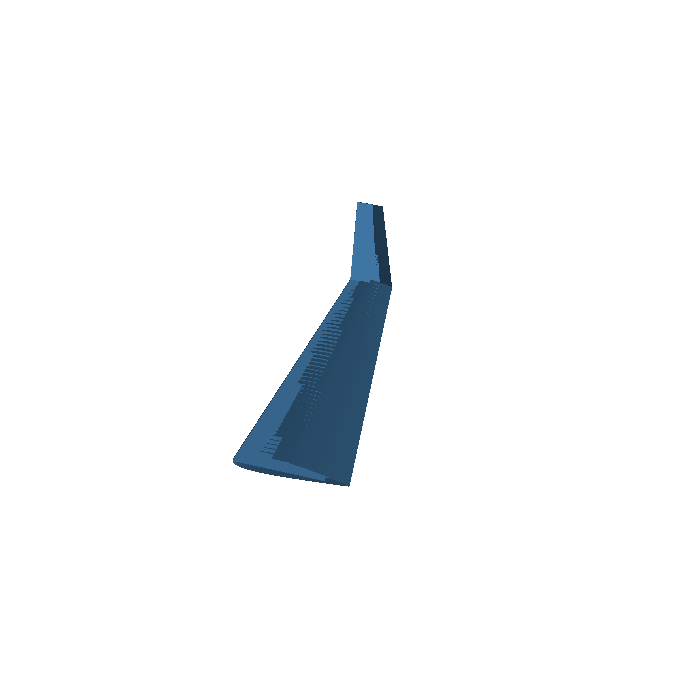

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# -----------------------------
# Airfoil: NACA 4-digit (closed)
# -----------------------------
def naca4_closed_loop(n=120, m=0.02, p=0.4, t=0.12):
    """
    Return a CLOSED airfoil loop (x,z) with EXACTLY n points (n even).
    Ordering: upper LE->TE, then lower TE->LE (no duplicate LE/TE).
    """
    assert n % 2 == 0 and n >= 6
    n_half = n // 2

    # Cosine spacing for LE/TE resolution
    beta = np.linspace(0.0, np.pi, n_half + 1)
    x = 0.5 * (1.0 - np.cos(beta))        # [0,1]
    x_safe = np.clip(x, 0.0, 1.0)

    # NACA thickness & camber
    yt = 5*t*(0.2969*np.sqrt(x_safe) - 0.1260*x - 0.3516*x**2
              + 0.2843*x**3 - 0.1015*x**4)
    yc = np.where(x < p, m/p**2*(2*p*x - x**2),
                        m/(1-p)**2*((1 - 2*p) + 2*p*x - x**2))
    dyc = np.where(x < p, 2*m/p**2*(p - x),
                        2*m/(1-p)**2*(p - x))
    th = np.arctan(dyc)

    xu = x - yt*np.sin(th); zu = yc + yt*np.cos(th)
    xl = x + yt*np.sin(th); zl = yc - yt*np.cos(th)

    # Closed loop: upper LE->TE, then lower TE->LE (drop duplicates)
    upper_x = xu[::-1]               # length n_half+1
    upper_z = zu[::-1]
    lower_x = xl[1:-1][::-1]         # length n_half-1
    lower_z = zl[1:-1][::-1]

    x_loop = np.concatenate([upper_x, lower_x])  # n points
    z_loop = np.concatenate([upper_z, lower_z])
    return x_loop, z_loop

def smoothstep(t):
    return t*t*(3.0 - 2.0*t)

# -----------------------------
# Wing + Winglet proportions
# -----------------------------
span        = 20.0    # half-span
c_root      = 5.0
c_tip       = 2.0
sweep_deg   = 18.0
sweep_off   = np.tan(np.deg2rad(sweep_deg)) * span
dihedral    = 0.0

# Smaller, realistic-ish winglet
wl_height     = 3.0            # vertical rise
wl_cant_out   = 0.6            # outward Y at top
wl_alpha_max  = 65.0           # rotation about chord axis at top (deg)
wl_top_chord  = 0.6 * c_tip    # slimmer winglet tip chord

# Discretization kept modest so it renders fast
n_chord = 120   # even; section resolution
n_wing  = 50    # wing stations (includes tip)
n_wl    = 30    # winglet stations (beyond tip)

# -----------------------------
# Sweep surface (stations x chord)
# -----------------------------
x_sec, z_sec = naca4_closed_loop(n=n_chord, m=0.02, p=0.4, t=0.12)
n_stations = n_wing + n_wl
X = np.zeros((n_stations, n_chord))
Y = np.zeros((n_stations, n_chord))
Z = np.zeros((n_stations, n_chord))

# Wing stations
for j in range(n_wing):
    s = j / (n_wing - 1)              # 0..1
    c = c_root + (c_tip - c_root) * s
    x_le = -sweep_off * s
    y    = span * s
    z0   = np.tan(np.deg2rad(dihedral)) * y

    X[j, :] = x_le + c * x_sec
    Y[j, :] = y
    Z[j, :] = z0   + c * z_sec

# Winglet stations (continuous blend)
for k in range(1, n_wl + 1):
    t = k / n_wl
    c = c_tip + (wl_top_chord - c_tip) * t
    x_le = -sweep_off

    alpha = np.deg2rad(wl_alpha_max) * smoothstep(t)  # smooth rotation
    ca, sa = np.cos(alpha), np.sin(alpha)

    y_base = span + wl_cant_out * t   # cant outward
    z_base = wl_height * t            # rise upward

    x_local = x_le + c * x_sec
    z_local = c * z_sec

    # rotate (x, 0, z) about x-axis by alpha
    y_rot = -z_local * sa
    z_rot =  z_local * ca

    X[n_wing - 1 + k, :] = x_local
    Y[n_wing - 1 + k, :] = y_base + y_rot
    Z[n_wing - 1 + k, :] = z_base + z_rot

# -----------------------------
# Plot only the surface
# -----------------------------
fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection='3d')

# fast-ish surface render
ax.plot_surface(X, Y, Z, rstride=1, cstride=3, color='steelblue',
                edgecolor='none', antialiased=False)

ax.view_init(elev=20, azim=-60)

# Equal-ish aspect (NumPy 2.x safe)
x_extent = float(np.ptp(X)); y_extent = float(np.ptp(Y)); z_extent = float(np.ptp(Z))
x_extent = max(x_extent, 1e-6); y_extent = max(y_extent, 1e-6); z_extent = max(z_extent, 1e-6)
ax.set_box_aspect([x_extent, y_extent, z_extent])

ax.set_axis_off()
plt.tight_layout()
plt.show()


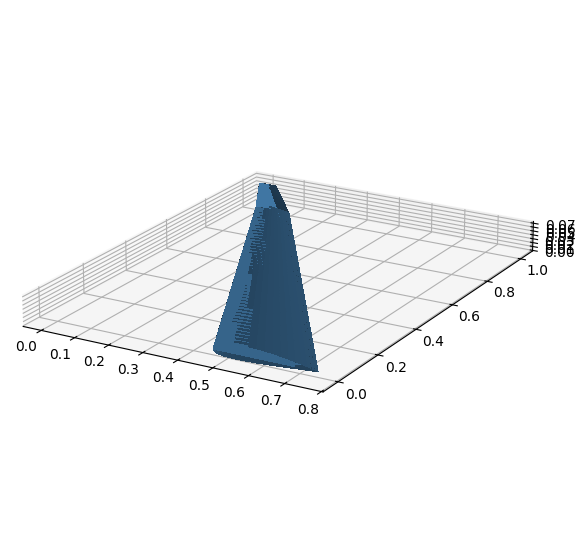

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# -----------------------------
# Airfoil: NACA 4-digit (closed)
# -----------------------------
def naca4_closed_loop(n=120, m=0.02, p=0.4, t=0.12):
    """
    CLOSED airfoil loop (x,z) with EXACTLY n points (n even).
    Ordering: upper LE->TE, then lower TE->LE (no duplicate LE/TE).
    """
    assert n % 2 == 0 and n >= 6
    n_half = n // 2
    beta = np.linspace(0.0, np.pi, n_half + 1)
    x = 0.5 * (1.0 - np.cos(beta))       # [0,1]
    x_safe = np.clip(x, 0.0, 1.0)

    # NACA thickness & camber
    yt = 5*0.12*(0.2969*np.sqrt(x_safe) - 0.1260*x - 0.3516*x**2
                 + 0.2843*x**3 - 0.1015*x**4)
    yc = np.where(x < p, m/p**2*(2*p*x - x**2),
                        m/(1-p)**2*((1 - 2*p) + 2*p*x - x**2))
    dyc = np.where(x < p, 2*m/p**2*(p - x),
                        2*m/(1-p)**2*(p - x))
    th = np.arctan(dyc)

    xu = x - yt*np.sin(th); zu = yc + yt*np.cos(th)
    xl = x + yt*np.sin(th); zl = yc - yt*np.cos(th)

    upper_x = xu[::-1]               # LE -> TE
    upper_z = zu[::-1]
    lower_x = xl[1:-1][::-1]         # TE -> LE (drop TE & LE)
    lower_z = zl[1:-1][::-1]

    x_loop = np.concatenate([upper_x, lower_x])  # n points
    z_loop = np.concatenate([upper_z, lower_z])
    return x_loop, z_loop

def smoothstep(t):  # smooth rotation blend
    return t*t*(3.0 - 2.0*t)

# -----------------------------
# More realistic proportions
# -----------------------------
half_span      = 20.0                 # arbitrary units (we'll normalize later)
taper_ratio    = 0.36                 # tip/root chord ratio (typical 0.3–0.45)
c_root         = 6.0
c_tip          = taper_ratio * c_root
sweep_LE_deg   = 25.0                 # 20–35° typical
dihedral_deg   = 0.0                  # keep 0 for clarity in this view

# Winglet as fraction of half-span (≈ 4–8%)
winglet_h_frac = 0.06                 # 6% of half-span
wl_height      = winglet_h_frac * half_span
wl_cant_out    = 0.02 * half_span     # small outward cant (~2% span)
wl_alpha_max   = 65.0                 # degrees rotation toward vertical
wl_top_chord   = 0.5 * c_tip          # slimmer chord at winglet tip

# Discretization (kept modest for speed)
n_chord = 120   # even
n_wing  = 50
n_wl    = 30

# -----------------------------
# Build continuous surface
# -----------------------------
x_sec, z_sec = naca4_closed_loop(n=n_chord, m=0.02, p=0.4, t=0.12)
sweep_off = np.tan(np.deg2rad(sweep_LE_deg)) * half_span
dihedral  = np.tan(np.deg2rad(dihedral_deg))

n_stations = n_wing + n_wl
X = np.zeros((n_stations, n_chord))
Y = np.zeros((n_stations, n_chord))
Z = np.zeros((n_stations, n_chord))

# Wing stations
for j in range(n_wing):
    s = j / (n_wing - 1)              # 0..1
    c = c_root + (c_tip - c_root) * s
    x_le = -sweep_off * s
    y    = half_span * s
    z0   = dihedral * y

    X[j, :] = x_le + c * x_sec
    Y[j, :] = y
    Z[j, :] = z0   + c * z_sec

# Winglet stations (continuous blend)
for k in range(1, n_wl + 1):
    t = k / n_wl
    c = c_tip + (wl_top_chord - c_tip) * t
    x_le = -sweep_off

    alpha = np.deg2rad(wl_alpha_max) * smoothstep(t)
    ca, sa = np.cos(alpha), np.sin(alpha)

    y_base = half_span + wl_cant_out * t
    z_base = wl_height * t

    x_local = x_le + c * x_sec
    z_local = c * z_sec

    y_rot = -z_local * sa
    z_rot =  z_local * ca

    X[n_wing - 1 + k, :] = x_local
    Y[n_wing - 1 + k, :] = y_base + y_rot
    Z[n_wing - 1 + k, :] = z_base + z_rot

# -----------------------------
# Uniformly normalize to unit cube [0,1]^3 (no distortion)
# -----------------------------
xmin, ymin, zmin = X.min(), Y.min(), Z.min()
xmax, ymax, zmax = X.max(), Y.max(), Z.max()
dx, dy, dz = xmax - xmin, ymax - ymin, zmax - zmin
scale = max(dx, dy, dz) if max(dx, dy, dz) > 0 else 1.0  # uniform scale
Xn = (X - xmin) / scale
Yn = (Y - ymin) / scale
Zn = (Z - zmin) / scale  # now the whole surface fits inside [0,1]^3

# -----------------------------
# Plot (parametric surface)
# -----------------------------
fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(Xn, Yn, Zn, rstride=1, cstride=3,
                color='steelblue', edgecolor='none', antialiased=False)

ax.view_init(elev=20, azim=-60)

# Aspect based on normalized extents
x_extent = float(np.ptp(Xn)); y_extent = float(np.ptp(Yn)); z_extent = float(np.ptp(Zn))
x_extent = max(x_extent, 1e-6); y_extent = max(y_extent, 1e-6); z_extent = max(z_extent, 1e-6)
ax.set_box_aspect([x_extent, y_extent, z_extent])



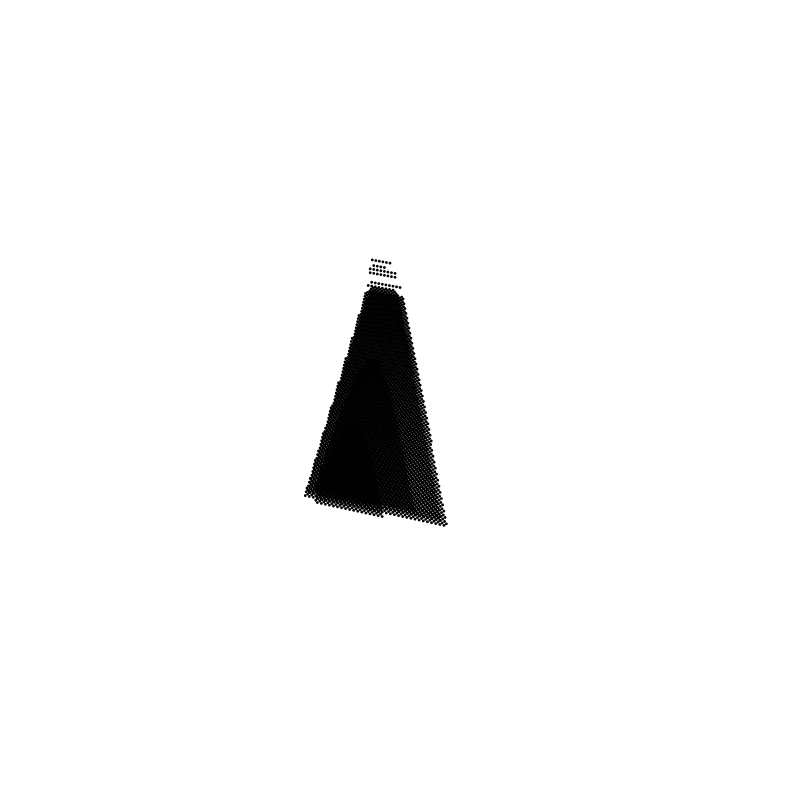

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import trimesh
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# -----------------------------
# Airfoil: NACA 4-digit (closed)
# -----------------------------
def naca4_closed_loop(n=120, m=0.02, p=0.4, t=0.12):
    """
    CLOSED airfoil loop (x,z) with EXACTLY n points (n even).
    Ordering: upper LE->TE, then lower TE->LE (no duplicate LE/TE).
    """
    assert n % 2 == 0 and n >= 6
    n_half = n // 2
    beta = np.linspace(0.0, np.pi, n_half + 1)
    x = 0.5 * (1.0 - np.cos(beta))       # [0,1]
    x_safe = np.clip(x, 0.0, 1.0)

    # NACA thickness & camber
    yt = 5*t*(0.2969*np.sqrt(x_safe) - 0.1260*x - 0.3516*x**2
              + 0.2843*x**3 - 0.1015*x**4)
    yc = np.where(x < p, m/p**2*(2*p*x - x**2),
                        m/(1-p)**2*((1 - 2*p) + 2*p*x - x**2))
    dyc = np.where(x < p, 2*m/p**2*(p - x),
                        2*m/(1-p)**2*(p - x))
    th = np.arctan(dyc)

    xu = x - yt*np.sin(th); zu = yc + yt*np.cos(th)
    xl = x + yt*np.sin(th); zl = yc - yt*np.cos(th)

    # Closed loop: upper LE->TE, then lower TE->LE, drop duplicates
    upper_x = xu[::-1]               # length n_half+1
    upper_z = zu[::-1]
    lower_x = xl[1:-1][::-1]         # length n_half-1
    lower_z = zl[1:-1][::-1]

    x_loop = np.concatenate([upper_x, lower_x])  # n points
    z_loop = np.concatenate([upper_z, lower_z])
    return x_loop, z_loop

def smoothstep(t):
    return t*t*(3.0 - 2.0*t)

# -----------------------------
# Realistic-ish proportions
# -----------------------------
half_span      = 20.0
taper_ratio    = 0.36
c_root         = 6.0
c_tip          = taper_ratio * c_root
sweep_LE_deg   = 25.0
dihedral_deg   = 0.0

# Winglet ≈ 6% half-span
winglet_h_frac = 0.06
wl_height      = winglet_h_frac * half_span
wl_cant_out    = 0.02 * half_span
wl_alpha_max   = 65.0
wl_top_chord   = 0.5 * c_tip

# Discretization (moderate for speed)
n_chord = 120   # even
n_wing  = 50
n_wl    = 30

# -----------------------------
# Build continuous surface
# -----------------------------
x_sec, z_sec = naca4_closed_loop(n=n_chord, m=0.02, p=0.4, t=0.12)
sweep_off = np.tan(np.deg2rad(sweep_LE_deg)) * half_span
dihedral  = np.tan(np.deg2rad(dihedral_deg))

n_stations = n_wing + n_wl
X = np.zeros((n_stations, n_chord))
Y = np.zeros((n_stations, n_chord))
Z = np.zeros((n_stations, n_chord))

# Wing stations
for j in range(n_wing):
    s = j / (n_wing - 1)
    c = c_root + (c_tip - c_root) * s
    x_le = -sweep_off * s
    y    = half_span * s
    z0   = dihedral * y

    X[j, :] = x_le + c * x_sec
    Y[j, :] = y
    Z[j, :] = z0   + c * z_sec

# Winglet stations (continuous blend)
for k in range(1, n_wl + 1):
    t = k / n_wl
    c = c_tip + (wl_top_chord - c_tip) * t
    x_le = -sweep_off

    alpha = np.deg2rad(wl_alpha_max) * smoothstep(t)
    ca, sa = np.cos(alpha), np.sin(alpha)

    y_base = half_span + wl_cant_out * t
    z_base = wl_height * t

    x_local = x_le + c * x_sec
    z_local = c * z_sec

    y_rot = -z_local * sa
    z_rot =  z_local * ca

    X[n_wing - 1 + k, :] = x_local
    Y[n_wing - 1 + k, :] = y_base + y_rot
    Z[n_wing - 1 + k, :] = z_base + z_rot

# -----------------------------
# Normalize to unit cube [0,1]^3, then center to [-0.5,0.5]^3
# -----------------------------
xmin, ymin, zmin = X.min(), Y.min(), Z.min()
xmax, ymax, zmax = X.max(), Y.max(), Z.max()
dx, dy, dz = xmax - xmin, ymax - ymin, zmax - zmin
scale = max(dx, dy, dz) if max(dx, dy, dz) > 0 else 1.0
Xn = (X - xmin) / scale
Yn = (Y - ymin) / scale
Zn = (Z - zmin) / scale

# Centered wing coords in [-0.5, 0.5]^3
Xc = Xn - 0.5
Yc = Yn - 0.5
Zc = Zn - 0.5

# -----------------------------
# Build watertight mesh (for inside test)
# -----------------------------
def triangulate_swept_cyclic(X, Y, Z):
    rows, cols = X.shape
    V = np.column_stack([X.ravel(), Y.ravel(), Z.ravel()])
    faces = []

    # side surface with cyclic chord wrap
    for i in range(rows - 1):
        base0 = i * cols
        base1 = (i + 1) * cols
        for j in range(cols):
            jn = (j + 1) % cols
            a = base0 + j
            b = base0 + jn
            c = base1 + j
            d = base1 + jn
            faces.append([a, c, b])
            faces.append([b, c, d])

    # cap at root (station 0)
    loop0 = np.arange(0, cols)
    centroid0 = V[loop0].mean(axis=0)
    idx_cent0 = V.shape[0]
    V = np.vstack([V, centroid0])
    for j in range(cols):
        a = loop0[j]
        b = loop0[(j + 1) % cols]
        c = idx_cent0
        faces.append([a, b, c])

    # cap at top (last station), reverse winding
    loop1 = np.arange((rows - 1) * cols, rows * cols)
    centroid1 = V[loop1].mean(axis=0)
    idx_cent1 = V.shape[0]
    V = np.vstack([V, centroid1])
    for j in range(cols):
        a = loop1[j]
        b = loop1[(j + 1) % cols]
        c = idx_cent1
        faces.append([b, a, c])

    F = np.asarray(faces, dtype=np.int64)
    return trimesh.Trimesh(vertices=V, faces=F, process=True)

mesh = triangulate_swept_cyclic(Xc, Yc, Zc)
# print("Watertight:", mesh.is_watertight)

# -----------------------------
# Big box: 4× the original size => [-2, 2]^3
# Indicator χ(x): 0 inside, 1 outside
# -----------------------------
def indicator(points_xyz):
    pts = np.asarray(points_xyz, dtype=float)
    inside = mesh.contains(pts)   # boolean per point
    return (~inside).astype(np.uint8)

# Regular grid in the big box
# (Keep resolution moderate so scatter is fast; bump if you like.)
p = 9
nx, ny, nz = 2**p, 2**p, 2**p
gx = np.linspace(-2.0, 2.0, nx)
gy = np.linspace(-2.0, 2.0, ny)
gz = np.linspace(-2.0, 2.0, nz)
Gx, Gy, Gz = np.meshgrid(gx, gy, gz, indexing="ij")
grid_pts = np.stack([Gx, Gy, Gz], axis=-1).reshape(-1, 3)

# Compute indicator on the grid (0 inside, 1 outside)
# Chunk if you need to reduce memory:
mask_flat = indicator(grid_pts)

# -----------------------------
# Visualization: 3D scatter of inside points (black)
# Outside points omitted (transparent)
# -----------------------------
inside_pts = grid_pts[mask_flat == 0]

# Optional: subsample for speed/clarity if too many points
max_points = 300_000
if inside_pts.shape[0] > max_points:
    idx = np.random.choice(inside_pts.shape[0], max_points, replace=False)
    inside_pts = inside_pts[idx]

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(inside_pts[:,0], inside_pts[:,1], inside_pts[:,2],
           c="k", s=1, alpha=1.0, marker="o")

# Equal-ish aspect
ext = np.array([np.ptp(inside_pts[:,0]),
                np.ptp(inside_pts[:,1]),
                np.ptp(inside_pts[:,2])], dtype=float)
ext[ext == 0] = 1.0
ax.set_box_aspect(ext.tolist())

ax.view_init(elev=20, azim=-60)
ax.set_axis_off()
plt.tight_layout()
plt.show()


[Ray Engine] python
[Grid] Built grid of 134,217,728 points in 3.84s
[Mask] Creation took 20.92s for 134,217,728 points


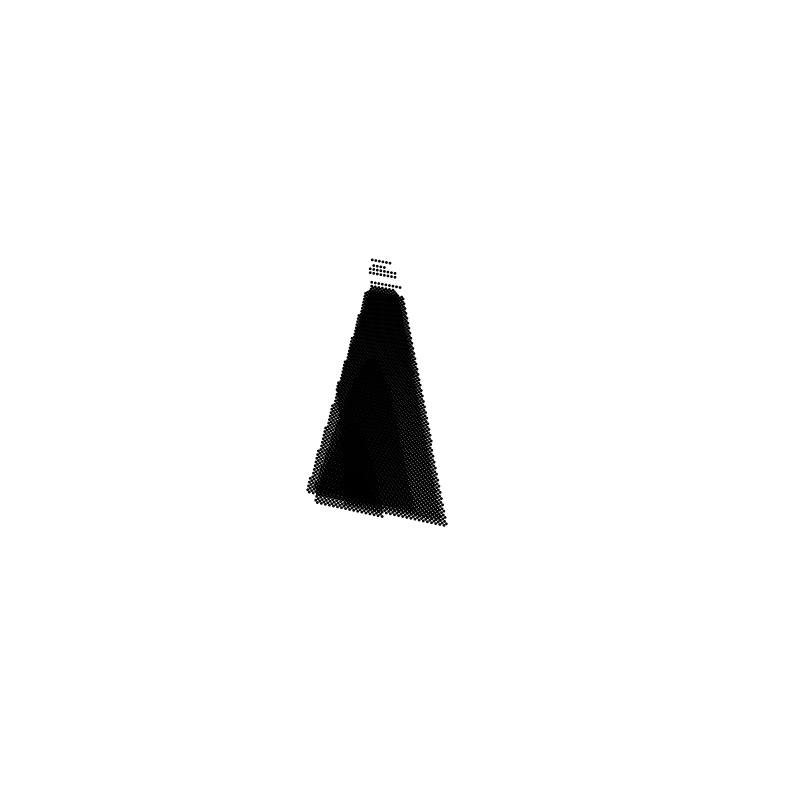

[Plot] Scatter plotting took 0.23s for 6,911 points shown


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import trimesh
import time
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# -----------------------------
# Airfoil: NACA 4-digit (closed)
# -----------------------------
def naca4_closed_loop(n=120, m=0.02, p=0.4, t=0.12):
    """
    CLOSED airfoil loop (x,z) with EXACTLY n points (n even).
    Ordering: upper LE->TE, then lower TE->LE (no duplicate LE/TE).
    """
    assert n % 2 == 0 and n >= 6
    n_half = n // 2
    beta = np.linspace(0.0, np.pi, n_half + 1)
    x = 0.5 * (1.0 - np.cos(beta))       # [0,1]
    x_safe = np.clip(x, 0.0, 1.0)

    # NACA thickness & camber
    yt = 5*t*(0.2969*np.sqrt(x_safe) - 0.1260*x - 0.3516*x**2
              + 0.2843*x**3 - 0.1015*x**4)
    yc = np.where(x < p, m/p**2*(2*p*x - x**2),
                        m/(1-p)**2*((1 - 2*p) + 2*p*x - x**2))
    dyc = np.where(x < p, 2*m/p**2*(p - x),
                        2*m/(1-p)**2*(p - x))
    th = np.arctan(dyc)

    xu = x - yt*np.sin(th); zu = yc + yt*np.cos(th)
    xl = x + yt*np.sin(th); zl = yc - yt*np.cos(th)

    # Closed loop: upper LE->TE, then lower TE->LE, drop duplicates
    upper_x = xu[::-1]               # length n_half+1
    upper_z = zu[::-1]
    lower_x = xl[1:-1][::-1]         # length n_half-1
    lower_z = zl[1:-1][::-1]

    x_loop = np.concatenate([upper_x, lower_x])  # n points
    z_loop = np.concatenate([upper_z, lower_z])
    return x_loop, z_loop

def smoothstep(t):
    return t*t*(3.0 - 2.0*t)

# -----------------------------
# Realistic-ish proportions
# -----------------------------
half_span      = 20.0
taper_ratio    = 0.36
c_root         = 6.0
c_tip          = taper_ratio * c_root
sweep_LE_deg   = 25.0
dihedral_deg   = 0.0

# Winglet ≈ 6% half-span
winglet_h_frac = 0.06
wl_height      = winglet_h_frac * half_span
wl_cant_out    = 0.02 * half_span
wl_alpha_max   = 65.0
wl_top_chord   = 0.5 * c_tip


p = 6
n_p = 2**p
# Discretization (moderate for speed)
n_chord = n_p   # even
n_wing  = n_p
n_wl    = n_p

# -----------------------------
# Build continuous surface
# -----------------------------
x_sec, z_sec = naca4_closed_loop(n=n_chord, m=0.02, p=0.4, t=0.12)
sweep_off = np.tan(np.deg2rad(sweep_LE_deg)) * half_span
dihedral  = np.tan(np.deg2rad(dihedral_deg))

n_stations = n_wing + n_wl
X = np.zeros((n_stations, n_chord))
Y = np.zeros((n_stations, n_chord))
Z = np.zeros((n_stations, n_chord))

# Wing stations
for j in range(n_wing):
    s = j / (n_wing - 1)
    c = c_root + (c_tip - c_root) * s
    x_le = -sweep_off * s
    y    = half_span * s
    z0   = dihedral * y

    X[j, :] = x_le + c * x_sec
    Y[j, :] = y
    Z[j, :] = z0   + c * z_sec

# Winglet stations (continuous blend)
for k in range(1, n_wl + 1):
    t = k / n_wl
    c = c_tip + (wl_top_chord - c_tip) * t
    x_le = -sweep_off

    alpha = np.deg2rad(wl_alpha_max) * smoothstep(t)
    ca, sa = np.cos(alpha), np.sin(alpha)

    y_base = half_span + wl_cant_out * t
    z_base = wl_height * t

    x_local = x_le + c * x_sec
    z_local = c * z_sec

    y_rot = -z_local * sa
    z_rot =  z_local * ca

    X[n_wing - 1 + k, :] = x_local
    Y[n_wing - 1 + k, :] = y_base + y_rot
    Z[n_wing - 1 + k, :] = z_base + z_rot

# -----------------------------
# Normalize to unit cube [0,1]^3, then center to [-0.5,0.5]^3
# (kept identical to your example)
# -----------------------------
xmin, ymin, zmin = X.min(), Y.min(), Z.min()
xmax, ymax, zmax = X.max(), Y.max(), Z.max()
dx, dy, dz = xmax - xmin, ymax - ymin, zmax - zmin
scale = max(dx, dy, dz) if max(dx, dy, dz) > 0 else 1.0
Xn = (X - xmin) / scale
Yn = (Y - ymin) / scale
Zn = (Z - zmin) / scale

# Centered wing coords in [-0.5, 0.5]^3
Xc = Xn - 0.5
Yc = Yn - 0.5
Zc = Zn - 0.5

# -----------------------------
# Build watertight mesh (for inside test)
# -----------------------------
def triangulate_swept_cyclic(X, Y, Z):
    rows, cols = X.shape
    V = np.column_stack([X.ravel(), Y.ravel(), Z.ravel()])
    faces = []

    # side surface with cyclic chord wrap
    for i in range(rows - 1):
        base0 = i * cols
        base1 = (i + 1) * cols
        for j in range(cols):
            jn = (j + 1) % cols
            a = base0 + j
            b = base0 + jn
            c = base1 + j
            d = base1 + jn
            faces.append([a, c, b])
            faces.append([b, c, d])

    # cap at root (station 0)
    loop0 = np.arange(0, cols)
    centroid0 = V[loop0].mean(axis=0)
    idx_cent0 = V.shape[0]
    V = np.vstack([V, centroid0])
    for j in range(cols):
        a = loop0[j]
        b = loop0[(j + 1) % cols]
        c = idx_cent0
        faces.append([a, b, c])

    # cap at top (last station), reverse winding
    loop1 = np.arange((rows - 1) * cols, rows * cols)
    centroid1 = V[loop1].mean(axis=0)
    idx_cent1 = V.shape[0]
    V = np.vstack([V, centroid1])
    for j in range(cols):
        a = loop1[j]
        b = loop1[(j + 1) % cols]
        c = idx_cent1
        faces.append([b, a, c])

    F = np.asarray(faces, dtype=np.int64)
    return trimesh.Trimesh(vertices=V, faces=F, process=True)

mesh = triangulate_swept_cyclic(Xc, Yc, Zc)

# -----------------------------
# Fast contains: Embree if available + chunking
# -----------------------------
try:
    from trimesh.ray.ray_pyembree import RayMeshIntersector
    ray_engine = "embree"
except Exception:
    from trimesh.ray.ray_triangle import RayMeshIntersector
    ray_engine = "python"

ray = RayMeshIntersector(mesh)
print(f"[Ray Engine] {ray_engine}")

def contains_points_fast(pts, chunk=250_000):
    pts = np.asarray(pts, dtype=float)
    inside = np.empty(pts.shape[0], dtype=bool)
    n = pts.shape[0]
    for i in range(0, n, chunk):
        sl = slice(i, min(i+chunk, n))
        inside[sl] = ray.contains_points(pts[sl])
    return inside

# -----------------------------
# Big box: 4× unit cube side → [-2, 2]^3 (as in your example)
# Grid and timings
# -----------------------------
p = 9                           # your example; 512^3 points → huge! adjust if needed
nx, ny, nz = 2**p, 2**p, 2**p
gx = np.linspace(-2.0, 2.0, nx)
gy = np.linspace(-2.0, 2.0, ny)
gz = np.linspace(-2.0, 2.0, nz)

t_grid0 = time.perf_counter()
Gx, Gy, Gz = np.meshgrid(gx, gy, gz, indexing="ij")
grid_pts = np.stack([Gx, Gy, Gz], axis=-1).reshape(-1, 3)
t_grid1 = time.perf_counter()
print(f"[Grid] Built grid of {grid_pts.shape[0]:,} points in {t_grid1 - t_grid0:.2f}s")

# -----------------------------
# TIMING A) Mask creation
# -----------------------------
t0 = time.perf_counter()
inside_bool = contains_points_fast(grid_pts, chunk=250_000)
mask_flat = (~inside_bool).astype(np.uint8)  # 0 inside, 1 outside
t1 = time.perf_counter()
print(f"[Mask] Creation took {t1 - t0:.2f}s for {grid_pts.shape[0]:,} points")

# -----------------------------
# TIMING B) Scatter plotting (inside points only)
# -----------------------------
inside_pts = grid_pts[mask_flat == 0]

# Optional subsample for speed/clarity
max_points = 300_000
if inside_pts.shape[0] > max_points:
    idx = np.random.choice(inside_pts.shape[0], max_points, replace=False)
    inside_pts = inside_pts[idx]

t2 = time.perf_counter()
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(inside_pts[:,0], inside_pts[:,1], inside_pts[:,2],
           c="k", s=1, alpha=1.0, marker="o")

# Equal-ish aspect
ext = np.array([np.ptp(inside_pts[:,0]),
                np.ptp(inside_pts[:,1]),
                np.ptp(inside_pts[:,2])], dtype=float)
ext[ext == 0] = 1.0
ax.set_box_aspect(ext.tolist())

ax.view_init(elev=20, azim=-60)
ax.set_axis_off()
plt.tight_layout()
plt.show()
t3 = time.perf_counter()
print(f"[Plot] Scatter plotting took {t3 - t2:.2f}s "
      f"for {inside_pts.shape[0]:,} points shown")


C:\Users\siddhartha.morales\AppData\Local\Temp\ipykernel_12468\2316786456.py:186: DeprecationWarning: `remove_degenerate_faces` is deprecated and will be removed in March 2024 replace with `self.update_faces(self.nondegenerate_faces(height=height))`
  mesh.remove_degenerate_faces()
C:\Users\siddhartha.morales\AppData\Local\Temp\ipykernel_12468\2316786456.py:187: DeprecationWarning: `remove_duplicate_faces` is deprecated and will be removed in March 2024: replace with `mesh.update_faces(mesh.unique_faces())`
  mesh.remove_duplicate_faces()


[Mesh] watertight=True, euler=2, faces=16,384
[Ray Engine] python
[Grid] Built 134,217,728 cell centers in 2.06s
[Mask] Creation took 10.89s, inside count = 5,801 (0.0043% of grid)


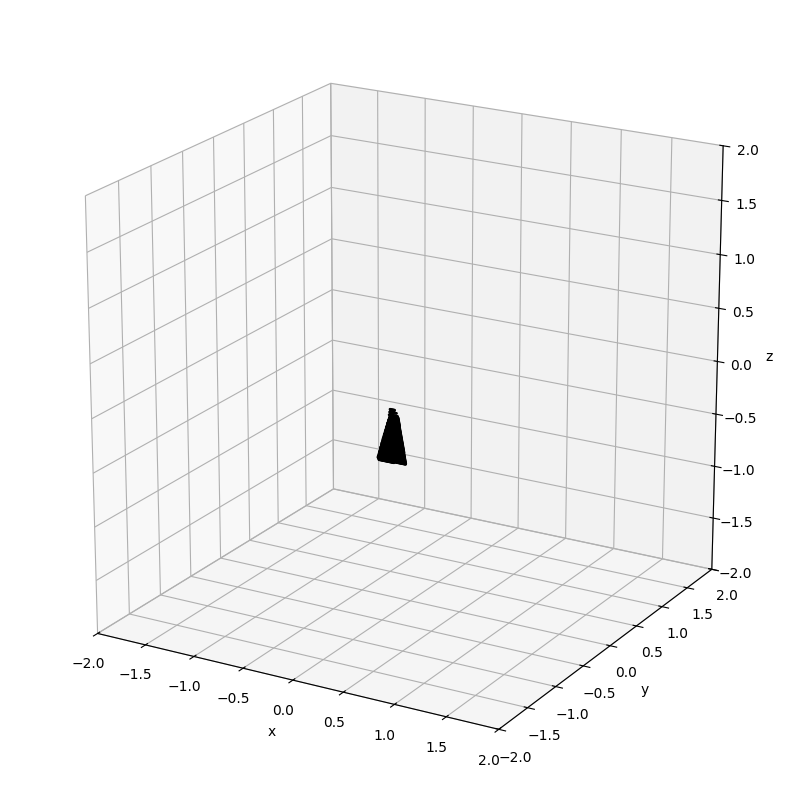

[Plot] Scatter plotting took 0.21s for 5,801 points shown


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import trimesh
import time
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# -----------------------------
# Airfoil: NACA 4-digit (closed)
# -----------------------------
def naca4_closed_loop(n=120, m=0.02, p=0.4, t=0.12):
    """
    CLOSED airfoil loop (x,z) with EXACTLY n points (n even).
    Ordering: upper LE->TE, then lower TE->LE (no duplicate LE/TE).
    """
    assert n % 2 == 0 and n >= 6
    n_half = n // 2
    beta = np.linspace(0.0, np.pi, n_half + 1)
    x = 0.5 * (1.0 - np.cos(beta))       # [0,1]
    x_safe = np.clip(x, 0.0, 1.0)

    # NACA thickness & camber
    yt = 5*t*(0.2969*np.sqrt(x_safe) - 0.1260*x - 0.3516*x**2
              + 0.2843*x**3 - 0.1015*x**4)
    yc = np.where(x < p, m/p**2*(2*p*x - x**2),
                        m/(1-p)**2*((1 - 2*p) + 2*p*x - x**2))
    dyc = np.where(x < p, 2*m/p**2*(p - x),
                        2*m/(1-p)**2*(p - x))
    th = np.arctan(dyc)

    xu = x - yt*np.sin(th); zu = yc + yt*np.cos(th)
    xl = x + yt*np.sin(th); zl = yc - yt*np.cos(th)

    # Closed loop: upper LE->TE, then lower TE->LE, drop duplicates
    upper_x = xu[::-1]               # length n_half+1
    upper_z = zu[::-1]
    lower_x = xl[1:-1][::-1]         # length n_half-1
    lower_z = zl[1:-1][::-1]

    x_loop = np.concatenate([upper_x, lower_x])  # n points
    z_loop = np.concatenate([upper_z, lower_z])
    return x_loop, z_loop

def smoothstep(t):
    return t*t*(3.0 - 2.0*t)

# -----------------------------
# Realistic-ish proportions
# -----------------------------
half_span      = 20.0
taper_ratio    = 0.36
c_root         = 6.0
c_tip          = taper_ratio * c_root
sweep_LE_deg   = 25.0
dihedral_deg   = 0.0

# Winglet ≈ 6% half-span
winglet_h_frac = 0.06
wl_height      = winglet_h_frac * half_span
wl_cant_out    = 0.02 * half_span
wl_alpha_max   = 65.0
wl_top_chord   = 0.5 * c_tip

# Grid exponent for wing discretization and mask grid
p = 6
n_p = 2**p

# Discretization (moderate for speed)
n_chord = n_p   # even
n_wing  = n_p
n_wl    = n_p

# -----------------------------
# Build continuous surface
# -----------------------------
x_sec, z_sec = naca4_closed_loop(n=n_chord, m=0.02, p=0.4, t=0.12)
sweep_off = np.tan(np.deg2rad(sweep_LE_deg)) * half_span
dihedral  = np.tan(np.deg2rad(dihedral_deg))

n_stations = n_wing + n_wl
X = np.zeros((n_stations, n_chord))
Y = np.zeros((n_stations, n_chord))
Z = np.zeros((n_stations, n_chord))

# Wing stations
for j in range(n_wing):
    s = j / (n_wing - 1)
    c = c_root + (c_tip - c_root) * s
    x_le = -sweep_off * s
    y    = half_span * s
    z0   = dihedral * y

    X[j, :] = x_le + c * x_sec
    Y[j, :] = y
    Z[j, :] = z0   + c * z_sec

# Winglet stations (continuous blend)
for k in range(1, n_wl + 1):
    t = k / n_wl
    c = c_tip + (wl_top_chord - c_tip) * t
    x_le = -sweep_off

    alpha = np.deg2rad(wl_alpha_max) * smoothstep(t)
    ca, sa = np.cos(alpha), np.sin(alpha)

    y_base = half_span + wl_cant_out * t
    z_base = wl_height * t

    x_local = x_le + c * x_sec
    z_local = c * z_sec

    y_rot = -z_local * sa
    z_rot =  z_local * ca

    X[n_wing - 1 + k, :] = x_local
    Y[n_wing - 1 + k, :] = y_base + y_rot
    Z[n_wing - 1 + k, :] = z_base + z_rot

# -----------------------------
# Normalize to unit cube [0,1]^3, then center to [-0.5,0.5]^3
# -----------------------------
xmin, ymin, zmin = X.min(), Y.min(), Z.min()
xmax, ymax, zmax = X.max(), Y.max(), Z.max()
dx, dy, dz = xmax - xmin, ymax - ymin, zmax - zmin
scale = max(dx, dy, dz) if max(dx, dy, dz) > 0 else 1.0
Xn = (X - xmin) / scale
Yn = (Y - ymin) / scale
Zn = (Z - zmin) / scale

# Centered wing coords in [-0.5, 0.5]^3
Xc = Xn - 0.5
Yc = Yn - 0.5
Zc = Zn - 0.5

# -----------------------------
# Build watertight mesh (for inside test)
# -----------------------------
def triangulate_swept_cyclic(X, Y, Z):
    rows, cols = X.shape
    V = np.column_stack([X.ravel(), Y.ravel(), Z.ravel()])
    faces = []

    # side surface with cyclic chord wrap
    for i in range(rows - 1):
        base0 = i * cols
        base1 = (i + 1) * cols
        for j in range(cols):
            jn = (j + 1) % cols
            a = base0 + j
            b = base0 + jn
            c = base1 + j
            d = base1 + jn
            faces.append([a, c, b])
            faces.append([b, c, d])

    # cap at root (station 0)
    loop0 = np.arange(0, cols)
    centroid0 = V[loop0].mean(axis=0)
    idx_cent0 = V.shape[0]
    V = np.vstack([V, centroid0])
    for j in range(cols):
        a = loop0[j]
        b = loop0[(j + 1) % cols]
        c = idx_cent0
        faces.append([a, b, c])

    # cap at top (last station), reverse winding
    loop1 = np.arange((rows - 1) * cols, rows * cols)
    centroid1 = V[loop1].mean(axis=0)
    idx_cent1 = V.shape[0]
    V = np.vstack([V, centroid1])
    for j in range(cols):
        a = loop1[j]
        b = loop1[(j + 1) % cols]
        c = idx_cent1
        faces.append([b, a, c])

    F = np.asarray(faces, dtype=np.int64)
    return trimesh.Trimesh(vertices=V, faces=F, process=True)

mesh = triangulate_swept_cyclic(Xc, Yc, Zc)

# --- repair (improves robustness of contains) ---
trimesh.repair.fix_inversion(mesh)
trimesh.repair.fix_normals(mesh)
trimesh.repair.fill_holes(mesh)
mesh.remove_degenerate_faces()
mesh.remove_duplicate_faces()
mesh.remove_infinite_values()
mesh.merge_vertices()
mesh.process(validate=True)
print(f"[Mesh] watertight={mesh.is_watertight}, euler={mesh.euler_number}, faces={len(mesh.faces):,}")

# -----------------------------
# Fast contains: Embree if available + chunking
# -----------------------------
try:
    from trimesh.ray.ray_pyembree import RayMeshIntersector
    ray_engine = "embree"
except Exception:
    from trimesh.ray.ray_triangle import RayMeshIntersector
    ray_engine = "python"

ray = RayMeshIntersector(mesh)
print(f"[Ray Engine] {ray_engine}")

def contains_points_fast(pts, chunk=250_000):
    pts = np.asarray(pts, dtype=float)
    inside = np.empty(pts.shape[0], dtype=bool)
    n = pts.shape[0]
    for i in range(0, n, chunk):
        sl = slice(i, min(i+chunk, n))
        inside[sl] = ray.contains_points(pts[sl])
    return inside

# -----------------------------
# Big box: [-2, 2]^3 (your example)
# Use CELL CENTERS, not edges, to avoid sampling exactly on the surface
# -----------------------------
p = 9                           # WARNING: 512^3 = 134,217,728 points (huge)
nx, ny, nz = 2**p, 2**p, 2**p

# build edges then take midpoints for cell centers
gx_edges = np.linspace(-2.0, 2.0, nx + 1)
gy_edges = np.linspace(-2.0, 2.0, ny + 1)
gz_edges = np.linspace(-2.0, 2.0, nz + 1)
gx = 0.5 * (gx_edges[:-1] + gx_edges[1:])
gy = 0.5 * (gy_edges[:-1] + gy_edges[1:])
gz = 0.5 * (gz_edges[:-1] + gz_edges[1:])

t_grid0 = time.perf_counter()
Gx, Gy, Gz = np.meshgrid(gx, gy, gz, indexing="ij")
grid_pts = np.stack([Gx, Gy, Gz], axis=-1).reshape(-1, 3)
t_grid1 = time.perf_counter()
print(f"[Grid] Built {grid_pts.shape[0]:,} cell centers in {t_grid1 - t_grid0:.2f}s")

# -----------------------------
# TIMING A) Mask creation
# -----------------------------
t0 = time.perf_counter()
inside_bool = contains_points_fast(grid_pts, chunk=250_000)
mask_flat = (~inside_bool).astype(np.uint8)  # 0 inside, 1 outside
t1 = time.perf_counter()
n_inside = int(np.count_nonzero(~mask_flat.astype(bool)))
print(f"[Mask] Creation took {t1 - t0:.2f}s, inside count = {n_inside:,} "
      f"({100.0*n_inside/grid_pts.shape[0]:.4f}% of grid)")

# -----------------------------
# TIMING B) Scatter plotting (inside only) with visible axis scales
# -----------------------------
inside_pts = grid_pts[mask_flat == 0]

# Optional subsample for speed/clarity
max_points = 300_000
if inside_pts.shape[0] > max_points:
    idx = np.random.choice(inside_pts.shape[0], max_points, replace=False)
    inside_pts = inside_pts[idx]

t2 = time.perf_counter()
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection="3d")

if inside_pts.size == 0:
    print("[Plot] No inside points at this grid resolution.")
else:
    ax.scatter(inside_pts[:,0], inside_pts[:,1], inside_pts[:,2],
               c="k", s=1, alpha=1.0, marker="o")

# Show axis scales and set limits for clarity
ax.set_xlim(-2.0, 2.0)
ax.set_ylim(-2.0, 2.0)
ax.set_zlim(-2.0, 2.0)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")

# Aspect taken from box extents
ax.set_box_aspect([4.0, 4.0, 4.0])  # since limits are [-2,2] in all axes

ax.view_init(elev=20, azim=-60)
plt.tight_layout()
plt.show()
t3 = time.perf_counter()
print(f"[Plot] Scatter plotting took {t3 - t2:.2f}s "
      f"for {inside_pts.shape[0]:,} points shown")


[Mesh] watertight=True
[Ray Engine] python
[Grid] 16,777,216 points
[Mask] took 17.47s, inside count=17,274


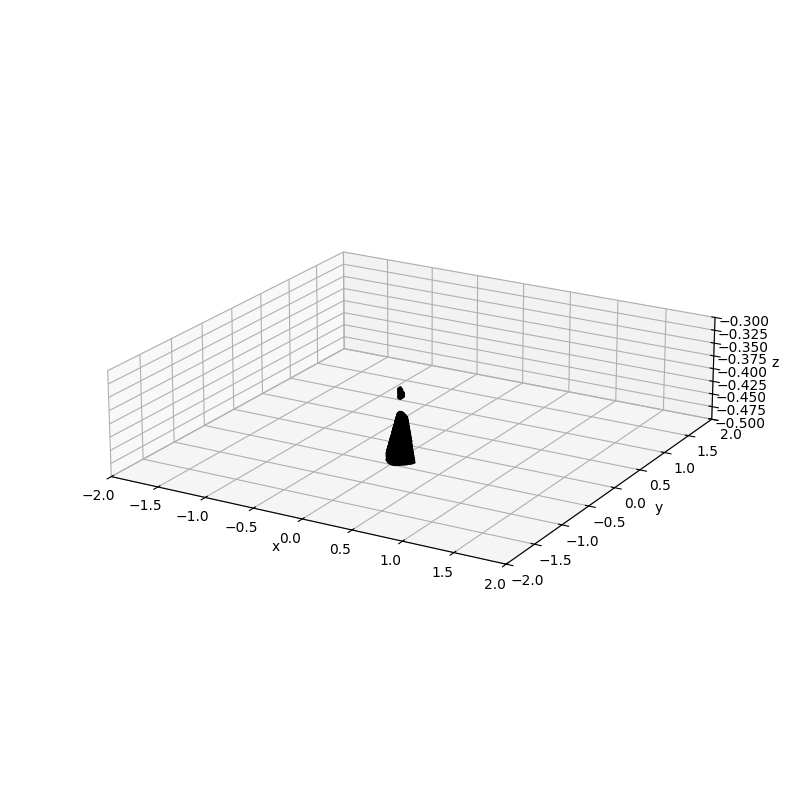

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import trimesh
import time
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# -----------------------------
# Airfoil: NACA 4-digit (closed)
# -----------------------------
def naca4_closed_loop(n=120, m=0.02, p=0.4, t=0.12):
    assert n % 2 == 0 and n >= 6
    n_half = n // 2
    beta = np.linspace(0.0, np.pi, n_half + 1)
    x = 0.5 * (1.0 - np.cos(beta))
    x_safe = np.clip(x, 0.0, 1.0)

    yt = 5*t*(0.2969*np.sqrt(x_safe) - 0.1260*x - 0.3516*x**2
              + 0.2843*x**3 - 0.1015*x**4)
    yc = np.where(x < p, m/p**2*(2*p*x - x**2),
                        m/(1-p)**2*((1 - 2*p) + 2*p*x - x**2))
    dyc = np.where(x < p, 2*m/p**2*(p - x),
                        2*m/(1-p)**2*(p - x))
    th = np.arctan(dyc)

    xu = x - yt*np.sin(th); zu = yc + yt*np.cos(th)
    xl = x + yt*np.sin(th); zl = yc - yt*np.cos(th)

    upper_x = xu[::-1]
    upper_z = zu[::-1]
    lower_x = xl[1:-1][::-1]
    lower_z = zl[1:-1][::-1]

    x_loop = np.concatenate([upper_x, lower_x])
    z_loop = np.concatenate([upper_z, lower_z])
    return x_loop, z_loop

def smoothstep(t):
    return t*t*(3.0 - 2.0*t)

# -----------------------------
# Wing + winglet proportions
# -----------------------------
half_span      = 20.0
taper_ratio    = 0.36
c_root         = 6.0
c_tip          = taper_ratio * c_root
sweep_LE_deg   = 25.0
dihedral_deg   = 0.0

winglet_h_frac = 0.06
wl_height      = winglet_h_frac * half_span
wl_cant_out    = 0.02 * half_span
wl_alpha_max   = 65.0
wl_top_chord   = 0.5 * c_tip

# -----------------------------
# Discretization
# -----------------------------
p = 6
n_p = 2**p
n_chord = n_p
n_wing  = n_p
n_wl    = n_p

# -----------------------------
# Build continuous surface
# -----------------------------
x_sec, z_sec = naca4_closed_loop(n=n_chord, m=0.02, p=0.4, t=0.12)
sweep_off = np.tan(np.deg2rad(sweep_LE_deg)) * half_span
dihedral  = np.tan(np.deg2rad(dihedral_deg))

n_stations = n_wing + n_wl
X = np.zeros((n_stations, n_chord))
Y = np.zeros((n_stations, n_chord))
Z = np.zeros((n_stations, n_chord))

# Wing stations
for j in range(n_wing):
    s = j / (n_wing - 1)
    c = c_root + (c_tip - c_root) * s
    x_le = -sweep_off * s
    y    = half_span * s
    z0   = dihedral * y

    X[j, :] = x_le + c * x_sec
    Y[j, :] = y
    Z[j, :] = z0   + c * z_sec

# Winglet stations (continuous blend)
for k in range(1, n_wl + 1):
    t = k / n_wl
    c = c_tip + (wl_top_chord - c_tip) * t
    x_le = -sweep_off

    alpha = np.deg2rad(wl_alpha_max) * smoothstep(t)
    ca, sa = np.cos(alpha), np.sin(alpha)

    y_base = half_span + wl_cant_out * t
    z_base = wl_height * t

    x_local = x_le + c * x_sec
    z_local = c * z_sec

    y_rot = -z_local * sa
    z_rot =  z_local * ca

    X[n_wing - 1 + k, :] = x_local
    Y[n_wing - 1 + k, :] = y_base + y_rot
    Z[n_wing - 1 + k, :] = z_base + z_rot

# -----------------------------
# Normalize to unit cube [0,1]^3, then center to [-0.5,0.5]^3
# -----------------------------
xmin, ymin, zmin = X.min(), Y.min(), Z.min()
xmax, ymax, zmax = X.max(), Y.max(), Z.max()
scale = max(xmax-xmin, ymax-ymin, zmax-zmin)
Xc = (X - xmin)/scale - 0.5
Yc = (Y - ymin)/scale - 0.5
Zc = (Z - zmin)/scale - 0.5

# -----------------------------
# Build watertight mesh
# -----------------------------
def triangulate_swept_cyclic(X, Y, Z):
    rows, cols = X.shape
    V = np.column_stack([X.ravel(), Y.ravel(), Z.ravel()])
    faces = []
    for i in range(rows - 1):
        base0 = i * cols
        base1 = (i + 1) * cols
        for j in range(cols):
            jn = (j + 1) % cols
            a = base0 + j
            b = base0 + jn
            c = base1 + j
            d = base1 + jn
            faces.append([a, c, b])
            faces.append([b, c, d])
    loop0 = np.arange(0, cols)
    centroid0 = V[loop0].mean(axis=0)
    V = np.vstack([V, centroid0])
    idx_cent0 = V.shape[0]-1
    for j in range(cols):
        a = loop0[j]; b = loop0[(j+1)%cols]
        faces.append([a, b, idx_cent0])
    loop1 = np.arange((rows-1)*cols, rows*cols)
    centroid1 = V[loop1].mean(axis=0)
    V = np.vstack([V, centroid1])
    idx_cent1 = V.shape[0]-1
    for j in range(cols):
        a = loop1[j]; b = loop1[(j+1)%cols]
        faces.append([b, a, idx_cent1])
    return trimesh.Trimesh(vertices=V, faces=np.array(faces), process=True)

mesh = triangulate_swept_cyclic(Xc, Yc, Zc)
print(f"[Mesh] watertight={mesh.is_watertight}")

# -----------------------------
# Fast contains
# -----------------------------
try:
    from trimesh.ray.ray_pyembree import RayMeshIntersector
    ray_engine = "embree"
except Exception:
    from trimesh.ray.ray_triangle import RayMeshIntersector
    ray_engine = "python"
ray = RayMeshIntersector(mesh)
print(f"[Ray Engine] {ray_engine}")

def contains_points_fast(pts, chunk=250_000):
    pts = np.asarray(pts, dtype=float)
    inside = np.empty(pts.shape[0], dtype=bool)
    for i in range(0, len(pts), chunk):
        inside[i:i+chunk] = ray.contains_points(pts[i:i+chunk])
    return inside

# -----------------------------
# Parallelepiped: x,y∈[-2,2], z∈[-0.5,0.5]
# -----------------------------
p = 8
nx, ny, nz = 2**p, 2**p, 2**p
gx = np.linspace(-2.0, 2.0, nx+1)
gy = np.linspace(-2.0, 2.0, ny+1)
gz = np.linspace(-0.5, -.3, nz+1)
gx = 0.5*(gx[:-1]+gx[1:])
gy = 0.5*(gy[:-1]+gy[1:])
gz = 0.5*(gz[:-1]+gz[1:])
Gx, Gy, Gz = np.meshgrid(gx, gy, gz, indexing="ij")
grid_pts = np.stack([Gx, Gy, Gz], -1).reshape(-1,3)
print(f"[Grid] {grid_pts.shape[0]:,} points")

# -----------------------------
# Mask creation
# -----------------------------
t0 = time.perf_counter()
inside_bool = contains_points_fast(grid_pts)
mask_flat = (~inside_bool).astype(np.uint8)
t1 = time.perf_counter()
print(f"[Mask] took {t1-t0:.2f}s, inside count={inside_bool.sum():,}")

# -----------------------------
# Scatter plot (inside only) with scales
# -----------------------------
inside_pts = grid_pts[mask_flat==0]
if inside_pts.shape[0] > 500_000:
    idx = np.random.choice(inside_pts.shape[0], 500_000, replace=False)
    inside_pts = inside_pts[idx]

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(inside_pts[:,0], inside_pts[:,1], inside_pts[:,2],
           c="k", s=1, alpha=1.0)

ax.set_xlim(-2,2)
ax.set_ylim(-2,2)
ax.set_zlim(-0.5,-.3)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_box_aspect([4,4,1])  # parallelepiped proportions
ax.view_init(elev=20, azim=-60)
plt.show()


C:\Users\siddhartha.morales\AppData\Local\Temp\ipykernel_12468\2531308386.py:160: DeprecationWarning: `remove_duplicate_faces` is deprecated and will be removed in March 2024: replace with `mesh.update_faces(mesh.unique_faces())`
  mesh.remove_duplicate_faces()


[Ray Engine] python


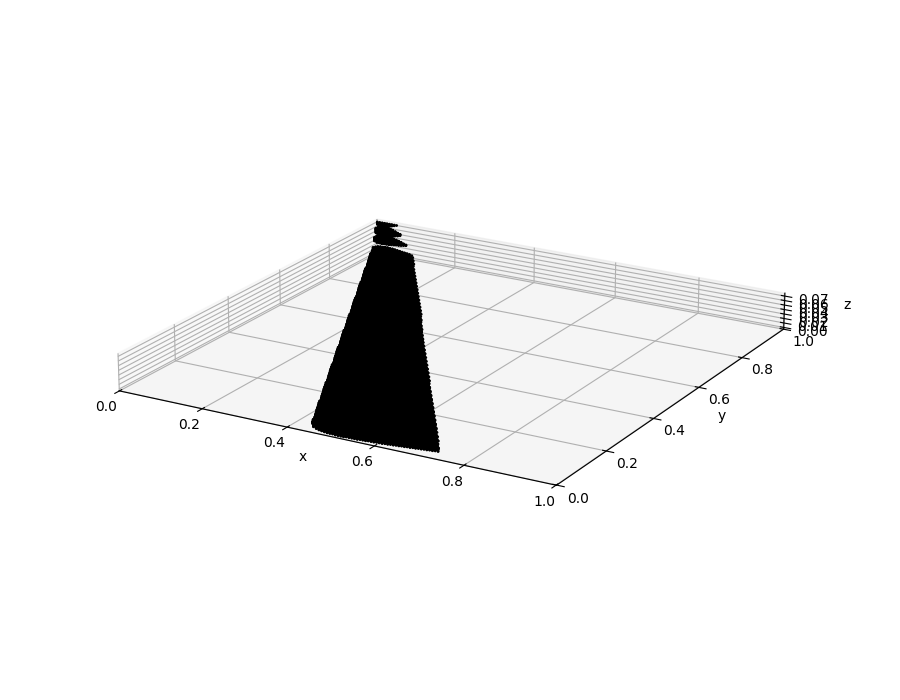

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import trimesh
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# -----------------------------
# Airfoil: NACA 4-digit (closed)
# -----------------------------
def naca4_closed_loop(n=120, m=0.02, p=0.4, t=0.12):
    """
    CLOSED airfoil loop (x,z) with EXACTLY n points (n even).
    Ordering: upper LE->TE, then lower TE->LE (no duplicate LE/TE).
    """
    assert n % 2 == 0 and n >= 6
    n_half = n // 2
    beta = np.linspace(0.0, np.pi, n_half + 1)
    x = 0.5 * (1.0 - np.cos(beta))       # [0,1]
    x_safe = np.clip(x, 0.0, 1.0)

    # NACA thickness & camber
    yt = 5*0.12*(0.2969*np.sqrt(x_safe) - 0.1260*x - 0.3516*x**2
                 + 0.2843*x**3 - 0.1015*x**4)
    yc = np.where(x < p, m/p**2*(2*p*x - x**2),
                        m/(1-p)**2*((1 - 2*p) + 2*p*x - x**2))
    dyc = np.where(x < p, 2*m/p**2*(p - x),
                        2*m/(1-p)**2*(p - x))
    th = np.arctan(dyc)

    xu = x - yt*np.sin(th); zu = yc + yt*np.cos(th)
    xl = x + yt*np.sin(th); zl = yc - yt*np.cos(th)

    upper_x = xu[::-1]               # LE -> TE
    upper_z = zu[::-1]
    lower_x = xl[1:-1][::-1]         # TE -> LE (drop TE & LE)
    lower_z = zl[1:-1][::-1]

    x_loop = np.concatenate([upper_x, lower_x])
    z_loop = np.concatenate([upper_z, lower_z])
    return x_loop, z_loop

def smoothstep(t):  # smooth rotation blend
    return t*t*(3.0 - 2.0*t)

# -----------------------------
# More realistic proportions
# -----------------------------
half_span      = 20.0
taper_ratio    = 0.36
c_root         = 6.0
c_tip          = taper_ratio * c_root
sweep_LE_deg   = 25.0
dihedral_deg   = 0.0

# Winglet as fraction of half-span (≈ 4–8%)
winglet_h_frac = 0.06
wl_height      = winglet_h_frac * half_span
wl_cant_out    = 0.02 * half_span
wl_alpha_max   = 65.0
wl_top_chord   = 0.5 * c_tip

# Discretization (kept modest for speed)
n_chord = 120   # even
n_wing  = 50
n_wl    = 30

# -----------------------------
# Build continuous surface
# -----------------------------
x_sec, z_sec = naca4_closed_loop(n=n_chord, m=0.02, p=0.4, t=0.12)
sweep_off = np.tan(np.deg2rad(sweep_LE_deg)) * half_span
dihedral  = np.tan(np.deg2rad(dihedral_deg))

n_stations = n_wing + n_wl
X = np.zeros((n_stations, n_chord))
Y = np.zeros((n_stations, n_chord))
Z = np.zeros((n_stations, n_chord))

# Wing stations
for j in range(n_wing):
    s = j / (n_wing - 1)              # 0..1
    c = c_root + (c_tip - c_root) * s
    x_le = -sweep_off * s
    y    = half_span * s
    z0   = dihedral * y

    X[j, :] = x_le + c * x_sec
    Y[j, :] = y
    Z[j, :] = z0   + c * z_sec

# Winglet stations (continuous blend)
for k in range(1, n_wl + 1):
    t = k / n_wl
    c = c_tip + (wl_top_chord - c_tip) * t
    x_le = -sweep_off

    alpha = np.deg2rad(wl_alpha_max) * smoothstep(t)
    ca, sa = np.cos(alpha), np.sin(alpha)

    y_base = half_span + wl_cant_out * t
    z_base = wl_height * t

    x_local = x_le + c * x_sec
    z_local = c * z_sec

    y_rot = -z_local * sa
    z_rot =  z_local * ca

    X[n_wing - 1 + k, :] = x_local
    Y[n_wing - 1 + k, :] = y_base + y_rot
    Z[n_wing - 1 + k, :] = z_base + z_rot

# -----------------------------
# Uniformly normalize to unit cube [0,1]^3 (no distortion)
# -----------------------------
xmin, ymin, zmin = X.min(), Y.min(), Z.min()
xmax, ymax, zmax = X.max(), Y.max(), Z.max()
scale = max(xmax-xmin, ymax-ymin, zmax-zmin) if max(xmax-xmin, ymax-ymin, zmax-zmin) > 0 else 1.0
Xn = (X - xmin) / scale
Yn = (Y - ymin) / scale
Zn = (Z - zmin) / scale  # entire surface in [0,1]^3

# =============================
# Build a watertight mesh (wing + winglet)
# =============================
def triangulate_swept_cyclic(X, Y, Z):
    rows, cols = X.shape
    V = np.column_stack([X.ravel(), Y.ravel(), Z.ravel()])
    faces = []
    # side surface with cyclic chord wrap
    for i in range(rows - 1):
        base0 = i * cols
        base1 = (i + 1) * cols
        for j in range(cols):
            jn = (j + 1) % cols
            a = base0 + j
            b = base0 + jn
            c = base1 + j
            d = base1 + jn
            faces.append([a, c, b])
            faces.append([b, c, d])
    # cap at root (station 0)
    loop0 = np.arange(0, cols)
    centroid0 = V[loop0].mean(axis=0)
    V = np.vstack([V, centroid0]); idx_cent0 = V.shape[0]-1
    for j in range(cols):
        a = loop0[j]; b = loop0[(j + 1) % cols]
        faces.append([a, b, idx_cent0])
    # cap at top (last station), reverse winding
    loop1 = np.arange((rows - 1) * cols, rows * cols)
    centroid1 = V[loop1].mean(axis=0)
    V = np.vstack([V, centroid1]); idx_cent1 = V.shape[0]-1
    for j in range(cols):
        a = loop1[j]; b = loop1[(j + 1) % cols]
        faces.append([b, a, idx_cent1])
    return trimesh.Trimesh(vertices=V, faces=np.asarray(faces, dtype=np.int64), process=True)

mesh = triangulate_swept_cyclic(Xn, Yn, Zn)
# light repair for robustness
trimesh.repair.fix_normals(mesh)
mesh.remove_duplicate_faces()
mesh.merge_vertices()
mesh.process(validate=True)

# =============================
# Indicator function χ(x) = 0 inside, 1 outside
# =============================
try:
    from trimesh.ray.ray_pyembree import RayMeshIntersector
    ray_engine = "embree"
except Exception:
    from trimesh.ray.ray_triangle import RayMeshIntersector
    ray_engine = "python"
ray = RayMeshIntersector(mesh)
print(f"[Ray Engine] {ray_engine}")

def wing_indicator(points_xyz, chunk=250_000):
    """
    Given (N,3) points in same coords as (Xn,Yn,Zn) ~ [0,1]^3,
    return mask: 0 if inside, 1 if outside.
    """
    pts = np.asarray(points_xyz, dtype=float).reshape(-1, 3)
    inside = np.empty(pts.shape[0], dtype=bool)
    for i in range(0, pts.shape[0], chunk):
        inside[i:i+chunk] = ray.contains_points(pts[i:i+chunk])
    return (~inside).astype(np.uint8)

# =============================
# Build a grid with Z limited to the wing height only
# =============================
# Use full x,y over [-m, 1+m], but z only over the object's true bounds
m_xy = 1e-3  # tiny margin in x,y
# object z bounds from the mesh itself
mn, mx = mesh.bounds
zmin_obj, zmax_obj = float(mn[2]), float(mx[2])
dz_obj = zmax_obj - zmin_obj
m_z = max(1e-4, 0.05 * dz_obj)  # small relative margin; also ensures nonzero

# grid resolution (tweak as needed)
nx, ny, nz = 160, 160, 96

# build edges then take midpoints (cell centers)
gx_edges = np.linspace(-m_xy, 1.0 + m_xy, nx + 1)
gy_edges = np.linspace(-m_xy, 1.0 + m_xy, ny + 1)
gz_edges = np.linspace(zmin_obj - m_z, zmax_obj + m_z, nz + 1)

gx = 0.5 * (gx_edges[:-1] + gx_edges[1:])
gy = 0.5 * (gy_edges[:-1] + gy_edges[1:])
gz = 0.5 * (gz_edges[:-1] + gz_edges[1:])

Gx, Gy, Gz = np.meshgrid(gx, gy, gz, indexing="ij")
grid_pts = np.stack([Gx, Gy, Gz], axis=-1).reshape(-1, 3)

# compute indicator
mask_flat = wing_indicator(grid_pts)  # 0 inside, 1 outside
inside_pts = grid_pts[mask_flat == 0]

# =============================
# Visualization: inside points only (outside = transparent)
# =============================
# Optional subsample for display speed
max_show = 300_000
if inside_pts.shape[0] > max_show:
    idx = np.random.choice(inside_pts.shape[0], max_show, replace=False)
    inside_pts = inside_pts[idx]

fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection='3d')
if inside_pts.size > 0:
    ax.scatter(inside_pts[:,0], inside_pts[:,1], inside_pts[:,2],
               c='k', s=1, alpha=1.0, marker='o')
else:
    print("[Viz] No inside points at this grid resolution.")

# show axis scales and use the *actual* z-limits of the wing (+margin)
ax.set_xlim(-m_xy, 1.0 + m_xy)
ax.set_ylim(-m_xy, 1.0 + m_xy)
ax.set_zlim(zmin_obj - m_z, zmax_obj + m_z)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")

# aspect based on plotted box extents
ax.set_box_aspect([
    (1.0 + 2*m_xy) - 0.0,
    (1.0 + 2*m_xy) - 0.0,
    (zmax_obj + m_z) - (zmin_obj - m_z)
])

ax.view_init(elev=20, azim=-60)
plt.tight_layout()
plt.show()


C:\Users\siddhartha.morales\AppData\Local\Temp\ipykernel_12468\748743145.py:161: DeprecationWarning: `remove_duplicate_faces` is deprecated and will be removed in March 2024: replace with `mesh.update_faces(mesh.unique_faces())`
  mesh.remove_duplicate_faces()


[Mesh] watertight=True, faces=19,200
[Ray Engine] python


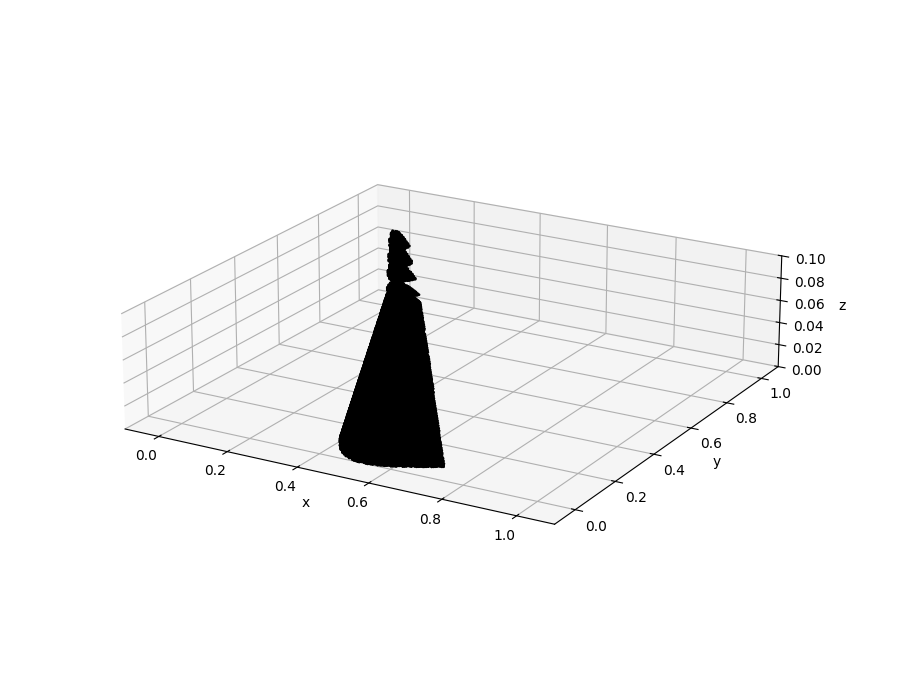

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import trimesh
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# -----------------------------
# Airfoil: NACA 4-digit (closed)
# -----------------------------
def naca4_closed_loop(n=120, m=0.02, p=0.4, t=0.12):
    """
    CLOSED airfoil loop (x,z) with EXACTLY n points (n even).
    Ordering: upper LE->TE, then lower TE->LE (no duplicate LE/TE).
    """
    assert n % 2 == 0 and n >= 6
    n_half = n // 2
    beta = np.linspace(0.0, np.pi, n_half + 1)
    x = 0.5 * (1.0 - np.cos(beta))       # [0,1]
    x_safe = np.clip(x, 0.0, 1.0)

    # NACA thickness & camber
    yt = 5*0.12*(0.2969*np.sqrt(x_safe) - 0.1260*x - 0.3516*x**2
                 + 0.2843*x**3 - 0.1015*x**4)
    yc = np.where(x < p, m/p**2*(2*p*x - x**2),
                        m/(1-p)**2*((1 - 2*p) + 2*p*x - x**2))
    dyc = np.where(x < p, 2*m/p**2*(p - x),
                        2*m/(1-p)**2*(p - x))
    th  = np.arctan(dyc)

    xu = x - yt*np.sin(th); zu = yc + yt*np.cos(th)
    xl = x + yt*np.sin(th); zl = yc - yt*np.cos(th)

    upper_x = xu[::-1]               # LE -> TE
    upper_z = zu[::-1]
    lower_x = xl[1:-1][::-1]         # TE -> LE (drop TE & LE)
    lower_z = zl[1:-1][::-1]

    x_loop = np.concatenate([upper_x, lower_x])  # n points
    z_loop = np.concatenate([upper_z, lower_z])
    return x_loop, z_loop

def smoothstep(t):  # smooth rotation blend
    return t*t*(3.0 - 2.0*t)

# -----------------------------
# Wing + winglet proportions
# -----------------------------
half_span      = 20.0
taper_ratio    = 0.36
c_root         = 6.0
c_tip          = taper_ratio * c_root
sweep_LE_deg   = 25.0
dihedral_deg   = 0.0

# Winglet
winglet_h_frac = 0.06
wl_height      = winglet_h_frac * half_span
wl_cant_out    = 0.02 * half_span
wl_alpha_max   = 65.0
wl_top_chord   = 0.5 * c_tip

# -----------------------------
# Discretization (kept modest)
# -----------------------------
n_chord = 120  # even
n_wing  = 50
n_wl    = 30

# -----------------------------
# Build continuous surface
# -----------------------------
x_sec, z_sec = naca4_closed_loop(n=n_chord, m=0.02, p=0.4, t=0.12)
sweep_off = np.tan(np.deg2rad(sweep_LE_deg)) * half_span
dihedral  = np.tan(np.deg2rad(dihedral_deg))

n_stations = n_wing + n_wl
X = np.zeros((n_stations, n_chord))
Y = np.zeros((n_stations, n_chord))
Z = np.zeros((n_stations, n_chord))

# Wing
for j in range(n_wing):
    s = j / (n_wing - 1)
    c = c_root + (c_tip - c_root) * s
    x_le = -sweep_off * s
    y    = half_span * s
    z0   = dihedral * y

    X[j, :] = x_le + c * x_sec
    Y[j, :] = y
    Z[j, :] = z0   + c * z_sec

# Winglet (continuous blend)
for k in range(1, n_wl + 1):
    t = k / n_wl
    c = c_tip + (wl_top_chord - c_tip) * t
    x_le = -sweep_off

    alpha = np.deg2rad(wl_alpha_max) * smoothstep(t)
    ca, sa = np.cos(alpha), np.sin(alpha)

    y_base = half_span + wl_cant_out * t
    z_base = wl_height * t

    x_local = x_le + c * x_sec
    z_local = c * z_sec

    y_rot = -z_local * sa
    z_rot =  z_local * ca

    X[n_wing - 1 + k, :] = x_local
    Y[n_wing - 1 + k, :] = y_base + y_rot
    Z[n_wing - 1 + k, :] = z_base + z_rot

# -----------------------------
# Normalize to unit cube [0,1]^3 (no distortion)
# -----------------------------
xmin, ymin, zmin = X.min(), Y.min(), Z.min()
xmax, ymax, zmax = X.max(), Y.max(), Z.max()
scale = max(xmax-xmin, ymax-ymin, zmax-zmin) if max(xmax-xmin, ymax-ymin, zmax-zmin) > 0 else 1.0
Xn = (X - xmin) / scale
Yn = (Y - ymin) / scale
Zn = (Z - zmin) / scale  # entire surface in [0,1]^3

# -----------------------------
# Build watertight mesh (wing + winglet)
# -----------------------------
def triangulate_swept_cyclic(X, Y, Z):
    rows, cols = X.shape
    V = np.column_stack([X.ravel(), Y.ravel(), Z.ravel()])
    faces = []
    # side surface with cyclic chord wrap
    for i in range(rows - 1):
        base0 = i * cols
        base1 = (i + 1) * cols
        for j in range(cols):
            jn = (j + 1) % cols
            a = base0 + j
            b = base0 + jn
            c = base1 + j
            d = base1 + jn
            faces.append([a, c, b])
            faces.append([b, c, d])
    # cap at root (station 0)
    loop0 = np.arange(0, cols)
    centroid0 = V[loop0].mean(axis=0)
    V = np.vstack([V, centroid0]); idx_cent0 = V.shape[0]-1
    for j in range(cols):
        a = loop0[j]; b = loop0[(j + 1) % cols]
        faces.append([a, b, idx_cent0])
    # cap at top (last station), reverse winding
    loop1 = np.arange((rows - 1) * cols, rows * cols)
    centroid1 = V[loop1].mean(axis=0)
    V = np.vstack([V, centroid1]); idx_cent1 = V.shape[0]-1
    for j in range(cols):
        a = loop1[j]; b = loop1[(j + 1) % cols]
        faces.append([b, a, idx_cent1])
    return trimesh.Trimesh(vertices=V, faces=np.asarray(faces, dtype=np.int64), process=True)

mesh = triangulate_swept_cyclic(Xn, Yn, Zn)
trimesh.repair.fix_normals(mesh)
mesh.remove_duplicate_faces()
mesh.merge_vertices()
mesh.process(validate=True)
print(f"[Mesh] watertight={mesh.is_watertight}, faces={len(mesh.faces):,}")

# -----------------------------
# Indicator function χ(x) = 0 inside, 1 outside
# -----------------------------
try:
    from trimesh.ray.ray_pyembree import RayMeshIntersector
    ray_engine = "embree"
except Exception:
    from trimesh.ray.ray_triangle import RayMeshIntersector
    ray_engine = "python"
ray = RayMeshIntersector(mesh)
print(f"[Ray Engine] {ray_engine}")

def wing_indicator(points_xyz, chunk=250_000):
    """
    Given (N,3) points in same coords as (Xn,Yn,Zn) ~ [0,1]^3,
    return mask: 0 if inside, 1 if outside.
    """
    pts = np.asarray(points_xyz, dtype=float).reshape(-1, 3)
    inside = np.empty(pts.shape[0], dtype=bool)
    for i in range(0, pts.shape[0], chunk):
        inside[i:i+chunk] = ray.contains_points(pts[i:i+chunk])
    return (~inside).astype(np.uint8)

# -----------------------------
# Grid for visualization:
# x,y over [-m, 1+m] (tiny margin), z over [0, 0.3]
# -----------------------------
m = 0.1
z_lim = 0.1
p = 8
nx, ny, nz = 2**p, 2**p, 2**p    # tweak for speed/quality
gx_edges = np.linspace(-m, 1.0 + m, nx + 1)
gy_edges = np.linspace(-m, 1.0 + m, ny + 1)
gz_edges = np.linspace(0.0, z_lim, nz + 1)

# sample at cell centers (avoid edge-on-surface hits)
gx = 0.5 * (gx_edges[:-1] + gx_edges[1:])
gy = 0.5 * (gy_edges[:-1] + gy_edges[1:])
gz = 0.5 * (gz_edges[:-1] + gz_edges[1:])

Gx, Gy, Gz = np.meshgrid(gx, gy, gz, indexing="ij")
grid_pts = np.stack([Gx, Gy, Gz], axis=-1).reshape(-1, 3)

# compute indicator
mask_flat = wing_indicator(grid_pts)   # 0 inside, 1 outside
inside_pts = grid_pts[mask_flat == 0]

# -----------------------------
# Visualization: inside points only (outside = transparent)
# -----------------------------
# subsample for display speed
max_show = 300_000
if inside_pts.shape[0] > max_show:
    idx = np.random.choice(inside_pts.shape[0], max_show, replace=False)
    inside_pts = inside_pts[idx]

fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection='3d')
if inside_pts.size > 0:
    ax.scatter(inside_pts[:,0], inside_pts[:,1], inside_pts[:,2],
               c='k', s=1, alpha=1.0, marker='o')
else:
    print("[Viz] No inside points at this grid resolution (increase nz or widen z-range slightly).")

# show axis scales; z specifically [0, 0.3]
ax.set_xlim(-m, 1.0 + m)
ax.set_ylim(-m, 1.0 + m)
ax.set_zlim(0.0,z_lim)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_box_aspect([1 + 2*m, 1 + 2*m, 0.3])  # aspect reflects the chosen slab

ax.view_init(elev=20, azim=-60)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import trimesh
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# -----------------------------
# Airfoil: NACA 4-digit (closed)
# -----------------------------
def naca4_closed_loop(n=120, m=0.02, p=0.4, t=0.12):
    assert n % 2 == 0 and n >= 6
    n_half = n // 2
    beta = np.linspace(0.0, np.pi, n_half + 1)
    x = 0.5 * (1.0 - np.cos(beta))       # [0,1]
    x_safe = np.clip(x, 0.0, 1.0)

    yt = 5*0.12*(0.2969*np.sqrt(x_safe) - 0.1260*x - 0.3516*x**2 \
                 + 0.2843*x**3 - 0.1015*x**4)
    yc = np.where(x < p, m/p**2*(2*p*x - x**2),
                        m/(1-p)**2*((1 - 2*p) + 2*p*x - x**2))
    dyc = np.where(x < p, 2*m/p**2*(p - x),
                        2*m/(1-p)**2*(p - x))
    th = np.arctan(dyc)

    xu = x - yt*np.sin(th); zu = yc + yt*np.cos(th)
    xl = x + yt*np.sin(th); zl = yc - yt*np.cos(th)

    upper_x = xu[::-1]               # LE -> TE
    upper_z = zu[::-1]
    lower_x = xl[1:-1][::-1]         # TE -> LE (drop TE & LE)
    lower_z = zl[1:-1][::-1]

    x_loop = np.concatenate([upper_x, lower_x])  # n points
    z_loop = np.concatenate([upper_z, lower_z])
    return x_loop, z_loop

def smoothstep(t):  # smooth rotation blend
    return t*t*(3.0 - 2.0*t)

# -----------------------------
# Wing + winglet proportions
# -----------------------------
half_span      = 20.0
taper_ratio    = 0.36
c_root         = 6.0
c_tip          = taper_ratio * c_root
sweep_LE_deg   = 25.0
dihedral_deg   = 0.0

# Winglet as fraction of half-span
winglet_h_frac = 0.06
wl_height      = winglet_h_frac * half_span
wl_cant_out    = 0.02 * half_span
wl_alpha_max   = 65.0
wl_top_chord   = 0.5 * c_tip

# -----------------------------
# Discretization (same as before)
# -----------------------------
n_chord = 120   # even
n_wing  = 50
n_wl    = 30

# -----------------------------
# Build continuous surface
# -----------------------------
x_sec, z_sec = naca4_closed_loop(n=n_chord, m=0.02, p=0.4, t=0.12)
sweep_off = np.tan(np.deg2rad(sweep_LE_deg)) * half_span
dihedral  = np.tan(np.deg2rad(dihedral_deg))

n_stations = n_wing + n_wl
X = np.zeros((n_stations, n_chord))
Y = np.zeros((n_stations, n_chord))
Z = np.zeros((n_stations, n_chord))

# Wing stations
for j in range(n_wing):
    s = j / (n_wing - 1)
    c = c_root + (c_tip - c_root) * s
    x_le = -sweep_off * s
    y    = half_span * s
    z0   = dihedral * y
    X[j,:] = x_le + c * x_sec
    Y[j,:] = y
    Z[j,:] = z0   + c * z_sec

# Winglet stations (continuous blend)
for k in range(1, n_wl + 1):
    t = k / n_wl
    c = c_tip + (wl_top_chord - c_tip) * t
    x_le = -sweep_off

    alpha = np.deg2rad(wl_alpha_max) * smoothstep(t)
    ca, sa = np.cos(alpha), np.sin(alpha)

    y_base = half_span + wl_cant_out * t
    z_base = wl_height * t

    x_local = x_le + c * x_sec
    z_local = c * z_sec

    y_rot = -z_local * sa
    z_rot =  z_local * ca

    X[n_wing - 1 + k,:] = x_local
    Y[n_wing - 1 + k,:] = y_base + y_rot
    Z[n_wing - 1 + k,:] = z_base + z_rot

# -----------------------------
# Normalize to unit cube [0,1]^3 (no distortion)
# -----------------------------
xmin, ymin, zmin = X.min(), Y.min(), Z.min()
xmax, ymax, zmax = X.max(), Y.max(), Z.max()
scale = max(xmax-xmin, ymax-ymin, zmax-zmin) if max(xmax-xmin, ymax-ymin, zmax-zmin) > 0 else 1.0
Xn = (X - xmin) / scale
Yn = (Y - ymin) / scale
Zn = (Z - zmin) / scale  # entire surface in [0,1]^3

# -----------------------------
# Watertight mesh (wing + winglet)
# -----------------------------
def triangulate_swept_cyclic(X, Y, Z):
    rows, cols = X.shape
    V = np.column_stack([X.ravel(), Y.ravel(), Z.ravel()])
    faces = []
    # side surface with cyclic chord wrap
    for i in range(rows - 1):
        b0 = i * cols
        b1 = (i + 1) * cols
        for j in range(cols):
            jn = (j + 1) % cols
            a = b0 + j;  b = b0 + jn;  c = b1 + j;  d = b1 + jn
            faces.append([a, c, b])
            faces.append([b, c, d])
    # root cap
    loop0 = np.arange(0, cols)
    centroid0 = V[loop0].mean(axis=0)
    V = np.vstack([V, centroid0]); idx0 = V.shape[0]-1
    for j in range(cols):
        a = loop0[j]; b = loop0[(j+1)%cols]
        faces.append([a, b, idx0])
    # tip/winglet-top cap (reverse winding)
    loop1 = np.arange((rows - 1)*cols, rows*cols)
    centroid1 = V[loop1].mean(axis=0)
    V = np.vstack([V, centroid1]); idx1 = V.shape[0]-1
    for j in range(cols):
        a = loop1[j]; b = loop1[(j+1)%cols]
        faces.append([b, a, idx1])

    return trimesh.Trimesh(vertices=V, faces=np.asarray(faces, dtype=np.int64), process=True)

mesh = triangulate_swept_cyclic(Xn, Yn, Zn)
trimesh.repair.fix_normals(mesh)
mesh.remove_duplicate_faces()
mesh.merge_vertices()
mesh.process(validate=True)
print(f"[Mesh] watertight={mesh.is_watertight}, faces={len(mesh.faces):,}")

# -----------------------------
# Ray intersector (Embree if available)
# -----------------------------
try:
    from trimesh.ray.ray_pyembree import RayMeshIntersector
    ray_engine = "embree"
except Exception:
    from trimesh.ray.ray_triangle import RayMeshIntersector
    ray_engine = "python"
ray = RayMeshIntersector(mesh)
print(f"[Ray Engine] {ray_engine}")

# -----------------------------
# Continuous mask φ(x)=0 inside, else 1-exp(-dz)
# where dz is the smallest |Δz| to a surface hit along ±z.
# -----------------------------
def min_vertical_distance_to_surface(pts, direction_sign=+1):
    """
    For each point, cast a ray parallel to ±z and return the minimum positive
    vertical distance |Δz| to the first intersection along that direction.
    If no hit, distance = +inf for that point.
    """
    N = pts.shape[0]
    dirs = np.tile([0.0, 0.0, float(np.sign(direction_sign))], (N, 1))
    # All rays start exactly at pts; to avoid immediate self-hit if on-surface,
    # apply a tiny epsilon shift along direction:
    eps = 1e-9
    origins = pts + eps * dirs

    # Get all intersections; then keep the minimal |Δz| per ray
    locs, idx_ray, _ = ray.intersects_location(origins, dirs)
    dz = np.full(N, np.inf, dtype=float)
    if len(idx_ray) > 0:
        # vertical distance along z
        dz_all = np.abs(locs[:, 2] - origins[idx_ray, 2])
        # reduce by min for each ray index
        np.minimum.at(dz, idx_ray, dz_all)
    return dz

def contains_points_fast(pts, chunk=250_000):
    inside = np.empty(pts.shape[0], dtype=bool)
    for i in range(0, pts.shape[0], chunk):
        sl = slice(i, min(i+chunk, pts.shape[0]))
        inside[sl] = ray.contains_points(pts[sl])
    return inside

def continuous_mask(points_xyz):
    """
    φ = 0 if inside mesh;
    φ = 1 - exp(-dz) if outside, dz = min vertical distance to surface along ±z.
    """
    pts = np.asarray(points_xyz, dtype=float).reshape(-1, 3)

    inside = contains_points_fast(pts)
    phi = np.zeros(pts.shape[0], dtype=float)

    if np.any(~inside):
        outside_pts = pts[~inside]

        dz_up   = min_vertical_distance_to_surface(outside_pts, +1)
        dz_down = min_vertical_distance_to_surface(outside_pts, -1)
        dz = np.minimum(dz_up, dz_down)

        # Fallback for rays that never hit (dz==inf): use Euclidean nearest distance
        missing = ~np.isfinite(dz)
        if np.any(missing):
            from trimesh.proximity import ProximityQuery
            pq = ProximityQuery(mesh)
            _, dist = pq.on_surface(outside_pts[missing])
            dz[missing] = dist  # use nearest Euclidean distance as a conservative fallback

        phi_out = 1.0 - np.exp(-dz)
        phi[~inside] = phi_out

    return phi  # 0..1

# -----------------------------
# Build sampling grid: x,y ∈ [-m,1+m], z ∈ [0, 0.3] (cell centers)
# -----------------------------
m = 1e-3
nx, ny, nz = 140, 140, 80  # adjust for speed/quality
gx_edges = np.linspace(-m, 1.0 + m, nx + 1)
gy_edges = np.linspace(-m, 1.0 + m, ny + 1)
gz_edges = np.linspace(0.0, 0.3, nz + 1)
gx = 0.5 * (gx_edges[:-1] + gx_edges[1:])
gy = 0.5 * (gy_edges[:-1] + gy_edges[1:])
gz = 0.5 * (gz_edges[:-1] + gz_edges[1:])
Gx, Gy, Gz = np.meshgrid(gx, gy, gz, indexing="ij")
grid_pts = np.stack([Gx, Gy, Gz], axis=-1).reshape(-1, 3)

# Compute continuous mask
phi = continuous_mask(grid_pts)   # 0 inside, →1 far outside

# -----------------------------
# Visualization
#   - color black with per-point alpha = φ
#   - inside (φ=0) fully black but invisible (alpha=0)
#   - far outside (φ→1) more visible (alpha→1)
# -----------------------------
# Build RGBA: all black, varying alpha
alphas = np.clip(phi, 0.0, 1.0)
colors = np.zeros((grid_pts.shape[0], 4), dtype=float)
colors[:, 3] = alphas  # RGBA with alpha = φ (R=G=B=0)

# Optional: subsample for display speed
max_show = 300_000
if grid_pts.shape[0] > max_show:
    idx = np.random.choice(grid_pts.shape[0], max_show, replace=False)
    P = grid_pts[idx]
    C = colors[idx]
else:
    P = grid_pts
    C = colors

fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(P[:,0], P[:,1], P[:,2], c=C, s=1, marker='o')
ax.set_xlim(-m, 1.0 + m)
ax.set_ylim(-m, 1.0 + m)
ax.set_zlim(0.0, 0.3)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_box_aspect([1+2*m, 1+2*m, 0.3])  # keep proportions of the slab
ax.view_init(elev=20, azim=-60)
plt.tight_layout()
plt.show()


C:\Users\siddhartha.morales\AppData\Local\Temp\ipykernel_19600\2742073408.py:153: DeprecationWarning: `remove_duplicate_faces` is deprecated and will be removed in March 2024: replace with `mesh.update_faces(mesh.unique_faces())`
  mesh.remove_duplicate_faces()


[Mesh] watertight=True, faces=19,200
[Ray Engine] python


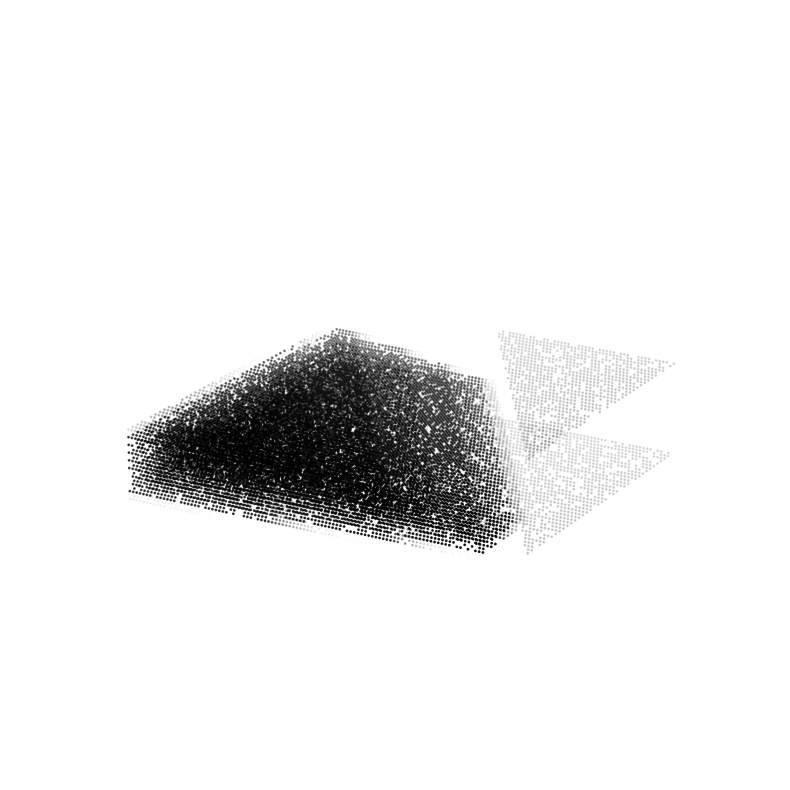

Ray engine: python | grid points: 250,000 | processed near-wing: 85,000, near-winglet: 0


In [12]:
import numpy as np
import matplotlib.pyplot as plt
import trimesh
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# =========================
# 1) Build the wing surface (same as your last)
# =========================
def naca4_closed_loop(n=120, m=0.02, p=0.4, t=0.12):
    assert n % 2 == 0 and n >= 6
    n_half = n // 2
    beta = np.linspace(0.0, np.pi, n_half + 1)
    x = 0.5 * (1.0 - np.cos(beta))
    x_safe = np.clip(x, 0.0, 1.0)
    yt = 5*t*(0.2969*np.sqrt(x_safe) - 0.1260*x - 0.3516*x**2
              + 0.2843*x**3 - 0.1015*x**4)
    yc = np.where(x < p, m/p**2*(2*p*x - x**2),
                        m/(1-p)**2*((1 - 2*p) + 2*p*x - x**2))
    dyc = np.where(x < p, 2*m/p**2*(p - x),
                        2*m/(1-p)**2*(p - x))
    th = np.arctan(dyc)
    xu = x - yt*np.sin(th); zu = yc + yt*np.cos(th)
    xl = x + yt*np.sin(th); zl = yc - yt*np.cos(th)
    upper_x = xu[::-1]; upper_z = zu[::-1]
    lower_x = xl[1:-1][::-1]; lower_z = zl[1:-1][::-1]
    x_loop = np.concatenate([upper_x, lower_x])
    z_loop = np.concatenate([upper_z, lower_z])
    return x_loop, z_loop

def smoothstep(t): return t*t*(3.0 - 2.0*t)

# Realistic-ish proportions
half_span      = 20.0
taper_ratio    = 0.36
c_root         = 6.0
c_tip          = taper_ratio * c_root
sweep_LE_deg   = 25.0
dihedral_deg   = 0.0
winglet_h_frac = 0.06
wl_height      = winglet_h_frac * half_span
wl_cant_out    = 0.02 * half_span
wl_alpha_max   = 65.0
wl_top_chord   = 0.5 * c_tip
n_chord, n_wing, n_wl = 120, 50, 30

x_sec, z_sec = naca4_closed_loop(n=n_chord, m=0.02, p=0.4, t=0.12)
sweep_off = np.tan(np.deg2rad(sweep_LE_deg)) * half_span
dihedral  = np.tan(np.deg2rad(dihedral_deg))
n_stations = n_wing + n_wl
X = np.zeros((n_stations, n_chord))
Y = np.zeros((n_stations, n_chord))
Z = np.zeros((n_stations, n_chord))

# Wing
for j in range(n_wing):
    s = j / (n_wing - 1)
    c = c_root + (c_tip - c_root) * s
    x_le = -sweep_off * s
    y    = half_span * s
    z0   = dihedral * y
    X[j,:] = x_le + c*x_sec
    Y[j,:] = y
    Z[j,:] = z0 + c*z_sec

# Winglet (continuous blend)
for k in range(1, n_wl+1):
    t = k / n_wl
    c = c_tip + (wl_top_chord - c_tip) * t
    x_le = -sweep_off
    alpha = np.deg2rad(wl_alpha_max) * smoothstep(t)
    ca, sa = np.cos(alpha), np.sin(alpha)
    y_base = half_span + wl_cant_out * t
    z_base = wl_height * t
    x_local = x_le + c*x_sec
    z_local = c*z_sec
    y_rot = -z_local*sa
    z_rot =  z_local*ca
    X[n_wing-1+k,:] = x_local
    Y[n_wing-1+k,:] = y_base + y_rot
    Z[n_wing-1+k,:] = z_base + z_rot

# Center (no rescale)
x_mid = 0.5*(X.min()+X.max()); y_mid = 0.5*(Y.min()+Y.max()); z_mid = 0.5*(Z.min()+Z.max())
Xc, Yc, Zc = X-x_mid, Y-y_mid, Z-z_mid
z_max = float(np.max(np.abs(Zc))) or 1.0
L = 2.0*z_max  # half-side; big cube is [-L, L]^3

# =========================
# 2) Lightweight ray helpers (no SDF fallback)
# =========================
def triangulate_swept_cyclic(Xs, Ys, Zs):
    rows, cols = Xs.shape
    V = np.column_stack([Xs.ravel(), Ys.ravel(), Zs.ravel()])
    faces = []
    for i in range(rows-1):
        b0 = i*cols; b1 = (i+1)*cols
        for j in range(cols):
            jn = (j+1) % cols
            a = b0 + j; b = b0 + jn; c = b1 + j; d = b1 + jn
            faces.append([a, c, b]); faces.append([b, c, d])
    loop0 = np.arange(0, cols)
    cent0 = V[loop0].mean(axis=0); idx0 = V.shape[0]
    V = np.vstack([V, cent0])
    for j in range(cols): faces.append([loop0[j], loop0[(j+1)%cols], idx0])
    loop1 = np.arange((rows-1)*cols, rows*cols)
    cent1 = V[loop1].mean(axis=0); idx1 = V.shape[0]
    V = np.vstack([V, cent1])
    for j in range(cols): faces.append([loop1[(j+1)%cols], loop1[j], idx1])
    return trimesh.Trimesh(vertices=V, faces=np.asarray(faces, np.int64), process=True)

wing_mesh    = triangulate_swept_cyclic(Xc[:n_wing,:],   Yc[:n_wing,:],   Zc[:n_wing,:])
winglet_mesh = triangulate_swept_cyclic(Xc[n_wing-1:,:], Yc[n_wing-1:,:], Zc[n_wing-1:,:])

try:
    from trimesh.ray.ray_pyembree import RayMeshIntersector
    RAY = "embree"
except Exception:
    from trimesh.ray.ray_triangle import RayMeshIntersector
    RAY = "python"

wing_ray    = RayMeshIntersector(wing_mesh)
winglet_ray = RayMeshIntersector(winglet_mesh)

def contains_chunked(intersector, pts, chunk=200_000):
    pts = np.asarray(pts, float)
    out = np.empty(pts.shape[0], dtype=bool)
    for i in range(0, pts.shape[0], chunk):
        sl = slice(i, min(i+chunk, pts.shape[0]))
        out[sl] = intersector.contains_points(pts[sl])
    return out

def axis_distance_light(intersector, pts, axis='z', chunk=150_000):
    """
    Directional distance along 'z' or 'x' *without SDF*.
    If both ±axis rays miss, fall back to AABB distance along that axis.
    """
    pts = np.asarray(pts, float)
    out = np.empty(pts.shape[0], float)
    mn, mx = intersector.mesh.bounds
    aidx = {'x':0, 'z':2}[axis]
    dir_pos = np.zeros(3); dir_pos[aidx] =  1.0
    dir_neg = np.zeros(3); dir_neg[aidx] = -1.0
    for i in range(0, pts.shape[0], chunk):
        sl = slice(i, min(i+chunk, pts.shape[0]))
        P = pts[sl]
        # +dir / -dir raycasts (single hit)
        loc_p, ind_p, _ = intersector.intersects_location(P, np.repeat(dir_pos[None,:], P.shape[0], axis=0), multiple_hits=False)
        loc_n, ind_n, _ = intersector.intersects_location(P, np.repeat(dir_neg[None,:], P.shape[0], axis=0), multiple_hits=False)
        d = np.full(P.shape[0], np.inf)
        if ind_p.size: d[ind_p] = np.minimum(d[ind_p], np.abs(loc_p[:, aidx] - P[ind_p, aidx]))
        if ind_n.size: d[ind_n] = np.minimum(d[ind_n], np.abs(loc_n[:, aidx] - P[ind_n, aidx]))
        # AABB fallback along axis (cheap)
        miss = ~np.isfinite(d)
        if np.any(miss):
            a_min, a_max = mn[aidx], mx[aidx]
            a = P[miss, aidx]
            da = np.where(a < a_min, a_min - a, np.where(a > a_max, a - a_max, np.minimum(a - a_min, a_max - a)))
            d[miss] = np.abs(da)
        out[sl] = d
    return out

# =========================
# 3) Grid with AABB prefilter (very light)
# =========================
# Big centered cube [-L, L]^3
nx, ny, nz = 100, 50, 50   # lighter grid; bump if needed
gx = np.linspace(-L, L, nx); gy = np.linspace(-L, L, ny); gz = np.linspace(-L, L, nz)
Gx, Gy, Gz = np.meshgrid(gx, gy, gz, indexing='ij')
grid_pts = np.stack([Gx, Gy, Gz], axis=-1).reshape(-1, 3)

# Prefilter: points far from each mesh's AABB won't contribute (set to 1)
def near_aabb(mask_mesh, pts, pad):
    mn, mx = mask_mesh.bounds
    mn = mn - pad; mx = mx + pad
    within = (pts[:,0] >= mn[0]) & (pts[:,0] <= mx[0]) & \
             (pts[:,1] >= mn[1]) & (pts[:,1] <= mx[1]) & \
             (pts[:,2] >= mn[2]) & (pts[:,2] <= mx[2])
    return within

pad = 0.1 * L  # small padding around each mesh AABB
near_wing    = near_aabb(wing_mesh,    grid_pts, pad)
near_winglet = near_aabb(winglet_mesh, grid_pts, pad)

# Initialize masks as 1 (outside)
wing_val    = np.ones(grid_pts.shape[0], float)
winglet_val = np.ones(grid_pts.shape[0], float)

# WING: only process near points
idx = np.where(near_wing)[0]
if idx.size:
    P = grid_pts[idx]
    inside = contains_chunked(wing_ray, P)
    wing_val[idx[inside]] = 0.0
    if np.any(~inside):
        dz = axis_distance_light(wing_ray, P[~inside], axis='z')
        wing_val[idx[~inside]] = 1.0 - np.exp(-100*dz)

# WINGLET: only process near points
idx2 = np.where(near_winglet)[0]
if idx2.size:
    P2 = grid_pts[idx2]
    inside2 = contains_chunked(winglet_ray, P2)
    winglet_val[idx2[inside2]] = 0.0
    if np.any(~inside2):
        dx = axis_distance_light(winglet_ray, P2[~inside2], axis='x')
        winglet_val[idx2[~inside2]] = 1.0 - np.exp(-100*dx)

# Combine (pointwise min)
val = np.minimum(wing_val, winglet_val)

# =========================
# 4) Lightweight visualization (scatter with alpha)
# =========================
alpha = 1.0 - np.clip(val, 0.0, 1.0)
colors = np.column_stack([np.zeros_like(alpha), np.zeros_like(alpha), np.zeros_like(alpha), alpha])

# subsample for speed if needed
max_points = 200_000
N = grid_pts.shape[0]
if N > max_points:
    idxp = np.random.choice(N, max_points, replace=False)
    Pshow, Cshow = grid_pts[idxp], colors[idxp]
else:
    Pshow, Cshow = grid_pts, colors

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(Pshow[:,0], Pshow[:,1], Pshow[:,2], s=1, c=Cshow, marker='o')

ext = np.array([np.ptp(Pshow[:,0]), np.ptp(Pshow[:,1]), np.ptp(Pshow[:,2])], float)
ext[ext==0] = 1.0
ax.set_box_aspect(ext.tolist())
ax.view_init(elev=20, azim=-60)
ax.set_axis_off()
plt.tight_layout()
plt.show()

print(f"Ray engine: {RAY} | grid points: {grid_pts.shape[0]:,} | processed near-wing: {near_wing.sum():,}, near-winglet: {near_winglet.sum():,}")
